## Experimenting with placing priors on GP nodes from plausible $n(z)$ realizations

### 1. Preparing, plotting, and reconstructing $n(z)$ using GP

In [2]:
# Necessary imports #

# General #

import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from scipy.stats import gaussian_kde
from copy import deepcopy
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)
import sys
import os

import euclidlib as el
import seaborn as sns

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)

# Gaussian processes

import matplotlib.pyplot as plt

from binz.run_gp import build_gp_nz 

import matplotlib as mpl 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

In [3]:
# Import and prepare original n(z) distribution #

zs = np.linspace(1e-4, 3, 100)
z, nz = el.phz.redshift_distributions('/home/jipdebuck/nzTabSPV3.fits')

def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz, z)
dndz_she_norm = normalize_dndz(nz, z)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z, zs)

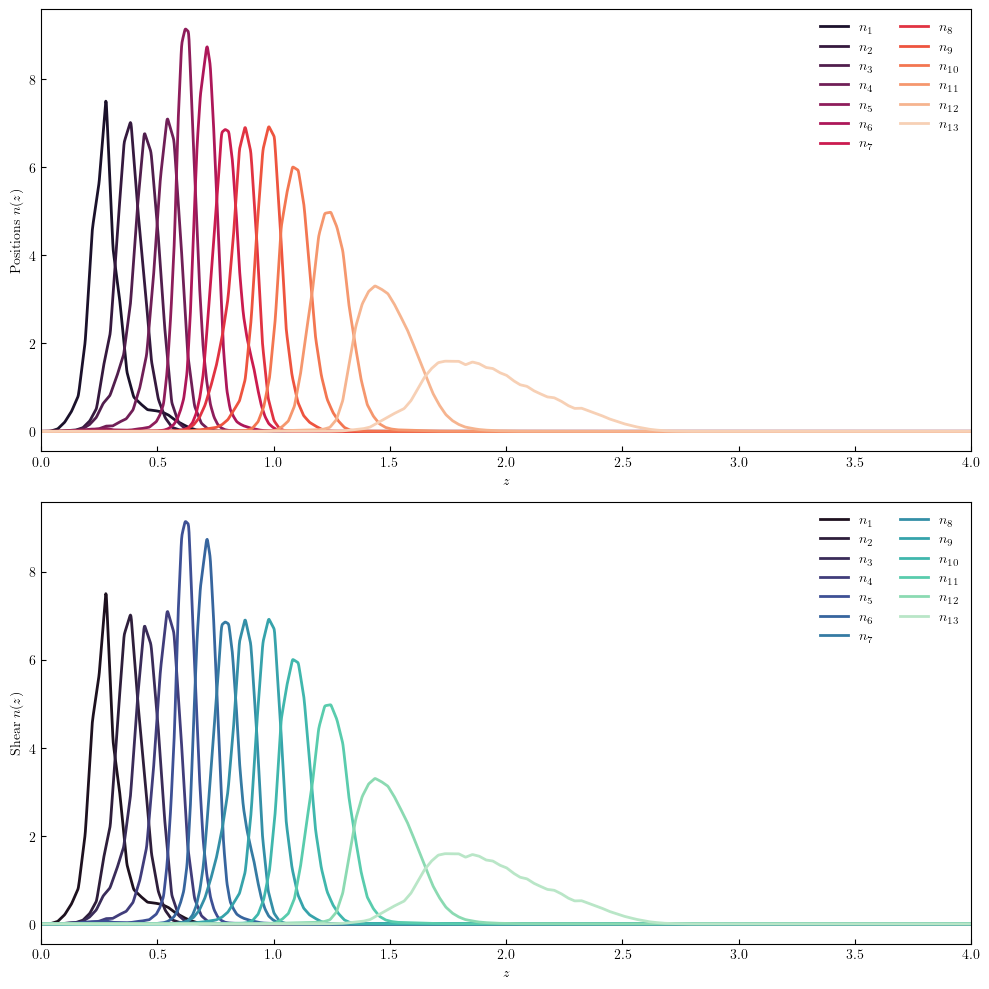

In [4]:
# Plotting of original n(z) distributions #

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [5]:
# Define parameters for GP reconstruction #

z_meds = []   # positions of median redshift for each bin
n_meds = []   # height of n(z) at median redshift for each bin

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z)
    n_med = nz[np.argmin(np.abs(z - z_med))]
    z_meds.append(z_med)
    n_meds.append(n_med)

corr_len = 0.03                                # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude

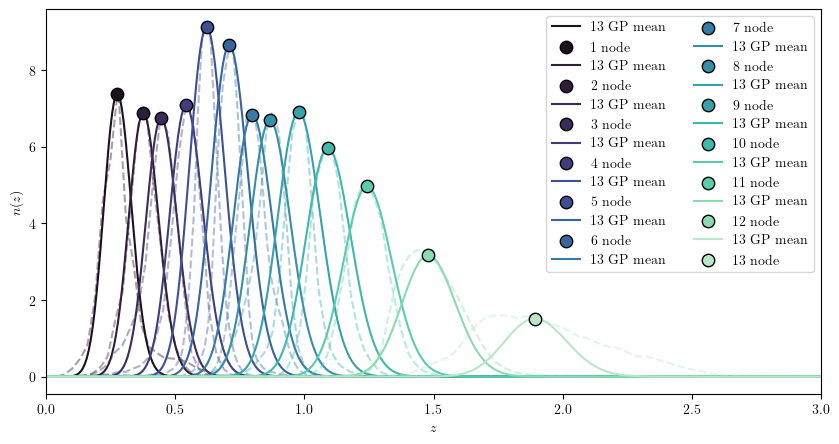

In [6]:
# GP reconstruction and plotting of results #

# Perform GP reconstruction #
priors, predictions = build_gp_nz(n_meds, z_meds, corr_len, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)

# Plot GP reconstruction results #
palette = sns.color_palette("mako", 13)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    #ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
    #                color=palette[j], alpha=0.2)

    ax.plot(z, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()


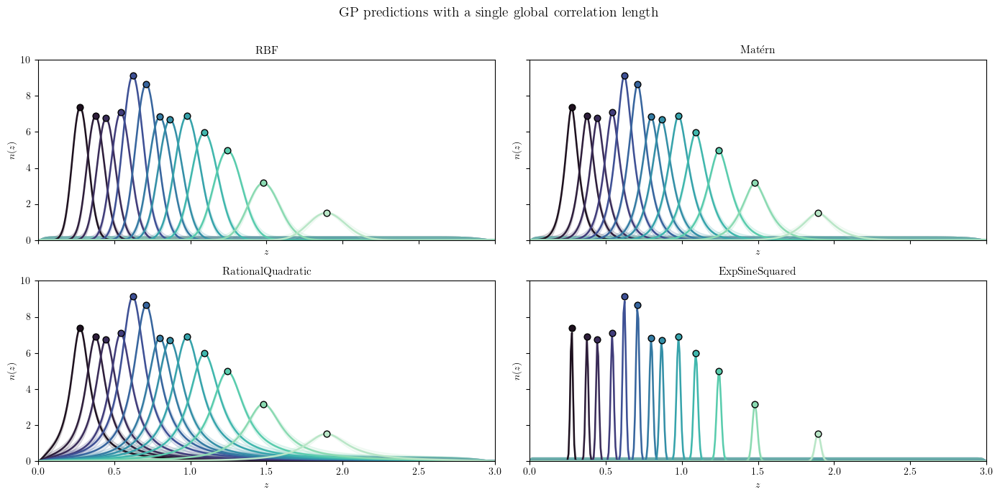

In [7]:
# Results using different kernels #

# Define different kernels #
kernel_dict = {
    "RBF": RBF,
    "Matérn": Matern,
    "RationalQuadratic": RationalQuadratic,
    "ExpSineSquared": ExpSineSquared
}

# Initialize figure for plotting #
n_kernels = len(kernel_dict)
palette = sns.color_palette("mako", len(dndz_she_norm))

fig, axs = plt.subplots(nrows=int(np.ceil(n_kernels/2)), ncols=2,
                        figsize=(14, 3.5 * int(np.ceil(n_kernels/2))),
                        sharex=True, sharey=True)
axs = axs.flatten()

# Compute and plot GP predictions for each kernel #
for ax, (kname, kernel) in zip(axs, kernel_dict.items()):
    
    z_meds = []
    n_meds = []
    for j, (key, nz) in enumerate(dndz_she_norm.items()):
        # --- Compute CDF and median node ---
        cdf = integrate.cumulative_trapezoid(nz, z, initial=0)
        cdf /= cdf[-1]
        z_med = np.interp(0.5, cdf, z)
        n_med = nz[np.argmin(np.abs(z - z_med))]
        z_meds.append(z_med)
        n_meds.append(n_med)

    
    gp_prior, gp_pred = build_gp_nz(n_meds, z_meds, corr_len, z_bounds, z_pred, alpha, kernel, nu, const_value, const_bounds)

    for j, nz in enumerate(n_meds):
        y_pred, y_std = gp_pred[j]
        ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} mean", lw=1.8)
        ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(),
                        (y_pred + y_std).ravel(), color=palette[j], alpha=0.15)
        ax.scatter(z_meds[j], nz, color=palette[j], edgecolor='black', s=40, zorder=3)

        ax.set_title(kname, fontsize=11)
        ax.set_xlim(0, 3)
        ax.set_ylim(0,10)
        ax.set_xlabel(r"$z$")
        ax.set_ylabel(r"$n(z)$")

for ax in axs[len(kernel_dict):]:
    ax.axis("off")

fig.suptitle("GP predictions with a single global correlation length", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### 2. Guada's work: GP informed by a training node sampled from a prior that is a mean of all possible realiations

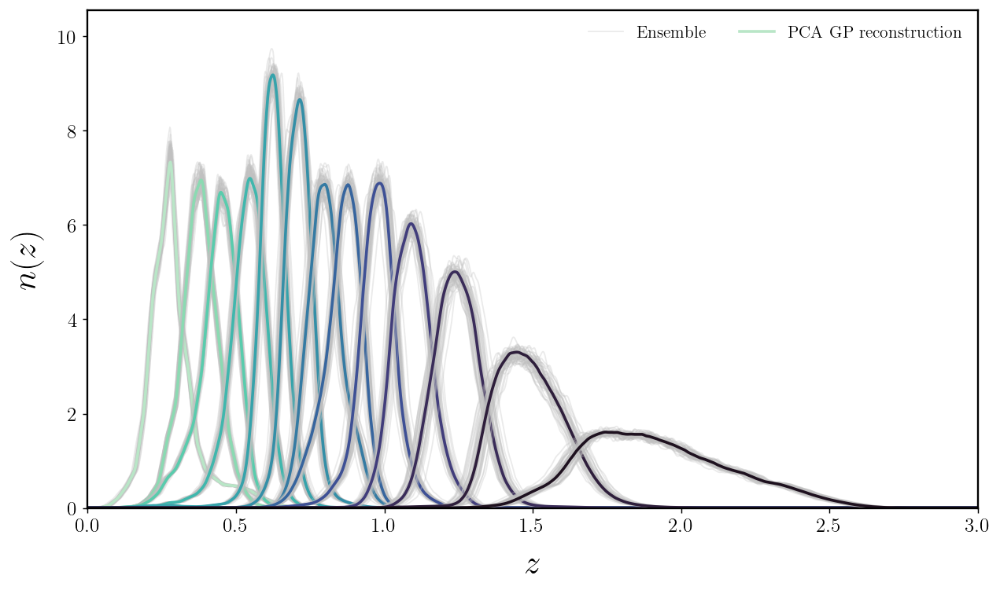

[1.00000000e-03 2.99966667e-03 4.99933333e-03 ... 5.99600067e+00
 5.99800033e+00 6.00000000e+00]


In [8]:
# Define the n(z) ensemble and redshift grid to evaluate on 

import numpy as np
from sklearn.decomposition import PCA


def build_pca_nz_prior(z_grid, nz_ensemble, n_components=5, log_eps=1e-12):
    """
    Build a PCA-based Gaussian prior for n(z) from an ensemble of plausible
    redshift distributions.

    Parameters
    ----------
    z_grid : (N_z,) array
        Redshift grid where all n(z) are evaluated.
    nz_ensemble : (N_ens, N_z) array
        Ensemble of plausible n(z) curves.
    n_components : int, optional
        Number of PCA modes to keep (default: 5).
    log_eps : float, optional
        Small number added inside the log to avoid -inf (default: 1e-12).

    Returns
    -------
    prior : dict
        Dictionary containing everything needed to work with the PCA prior:
        - 'z_grid'        : the redshift grid
        - 'pca'           : trained sklearn.decomposition.PCA object
        - 'coeff_mean'    : (k,) mean of PCA coefficients
        - 'coeff_cov'     : (k,k) covariance of PCA coefficients
        - 'n_components'  : number of retained components
        - 'log_eps'       : epsilon used in the log-transform
    """

    z_grid = np.asarray(z_grid)
    nz_ensemble = np.asarray(nz_ensemble)

    # Normalise each n(z) in the ensemble
    norms = np.trapezoid(nz_ensemble, z_grid, axis=1)
    nz_normed = nz_ensemble / norms[:, None]

    # Log-transform to enforce positivity in reconstruction
    f_ensemble = np.log(nz_normed + log_eps)

    # PCA in function space (each f(z) is a row)
    pca = PCA(n_components=n_components)
    coeffs = pca.fit_transform(f_ensemble)   # shape: (N_ens, k)

    # Empirical Gaussian prior on the PCA coefficients
    coeff_mean = np.mean(coeffs, axis=0)               # (k,)
    coeff_cov = np.cov(coeffs, rowvar=False)           # (k, k)

    prior = {
        "z_grid": z_grid,
        "pca": pca,
        "coeff_mean": coeff_mean,
        "coeff_cov": coeff_cov,
        "n_components": n_components,
        "log_eps": log_eps,
    }

    return prior


def sample_coeffs_from_prior(prior, n_samples=1, random_state=None):
    """
    Draw PCA coefficients from the Gaussian prior defined by the ensemble.

    Parameters
    ----------
    prior : dict
        Output of build_pca_nz_prior.
    n_samples : int, optional
        Number of coefficient vectors to sample (default: 1).
    random_state : int or np.random.Generator, optional
        Seed or RNG for reproducibility.

    Returns
    -------
    coeffs : (n_samples, k) array
        Sampled PCA coefficients.
    """
    mean = prior["coeff_mean"]
    cov = prior["coeff_cov"]

    if isinstance(random_state, np.random.Generator):
        rng = random_state
    else:
        rng = np.random.default_rng(random_state)

    coeffs = rng.multivariate_normal(mean, cov, size=n_samples)
    return coeffs


def reconstruct_nz_from_coeffs(prior, coeffs):
    """
    Reconstruct n(z) from PCA coefficients.

    Parameters
    ----------
    prior : dict
        Output of build_pca_nz_prior.
    coeffs : (k,) or (N, k) array
        PCA coefficients.

    Returns
    -------
    nz : (N_z,) or (N, N_z) array
        Reconstructed, normalised n(z) curves.
    """
    pca = prior["pca"]
    z_grid = prior["z_grid"]
    log_eps = prior["log_eps"]

    coeffs = np.atleast_2d(coeffs)  # (N, k)

    # Inverse PCA: back to f(z) = log n(z)
    f_rec = pca.inverse_transform(coeffs)  # (N, N_z)

    # Undo log-transform and renormalise each curve
    nz = np.exp(f_rec) - log_eps
    nz = np.clip(nz, 0.0, None)

    norms = np.trapezoid(nz, z_grid, axis=1)
    nz /= norms[:, None]

    # If input was 1D coefficients, return 1D n(z)
    if coeffs.shape[0] == 1:
        return nz[0]
    return nz


def best_fit_nz_from_prior(prior):
    """
    Convenience helper: return the 'best-fit' n(z) corresponding to the
    mean PCA coefficients (i.e. the ensemble mean in coefficient space).

    Parameters
    ----------
    prior : dict
        Output of build_pca_nz_prior.

    Returns
    -------
    nz_best : (N_z,) array
        Reconstructed n(z) from mean coefficients.
    """
    coeff_mean = prior["coeff_mean"]
    return reconstruct_nz_from_coeffs(prior, coeff_mean)

import numpy as np
from scipy.ndimage import gaussian_filter1d

def generate_bin1_ensemble(
    N_ens=5,
    z_lo=0.001,
    z_hi=6,
    N_z=3001,
    mean_shift_sigma=0.01,
    width_shift_sigma=0.02,
    shape_noise_sigma=0.07,
    smooth_scale=3,
    nz = dndz_she_norm[1]
):
    """
    Generate an ensemble of n(z) realisations for the FIRST bin only:
        z ∈ [0.001, 0.42]
    using small shifts + smooth perturbations.
    """

    # ---------------------------
    # 1. Grid + base bin n(z)
    # ---------------------------
    z = np.linspace(z_lo, z_hi, N_z)
    nz /= np.trapezoid(nz, z)        # ensure norm within [0, 3] part
    nz_bin = nz.copy()               # for first bin, that's it

    # ---------------------------
    # Build ensemble
    # ---------------------------
    ensemble = []

    z_mean = np.trapezoid(z * nz_bin, z)

    for _ in range(N_ens):

        # Mean shift
        dz = np.random.normal(0, mean_shift_sigma) * z_mean
        z_shift = np.clip(z + dz, z_lo, z_hi)

        # Width/stretch shift
        width = 1 + np.random.normal(0, width_shift_sigma)
        z_stretch = z_mean + width * (z_shift - z_mean)
        z_stretch = np.clip(z_stretch, z_lo, z_hi)

        # Smooth random shape fluctuation
        noise = np.random.normal(0, shape_noise_sigma, N_z)
        noise_smooth = gaussian_filter1d(noise, smooth_scale)
        nz_pert = nz_bin * (1 + noise_smooth)
        nz_pert = np.clip(nz_pert, 1e-12, None)

        # Interpolate to shifted grid
        nz_new = np.interp(z, z_stretch, nz_pert, left=0, right=0)

        # Normalise inside the bin
        nz_new /= np.trapezoid(nz_new, z)

        ensemble.append(nz_new)

    return z, np.array(ensemble)

z_ens_list, nz_ensemble_list = zip(*[
    generate_bin1_ensemble(
        N_ens=50, 
        nz=dndz_she_norm[i], 
        N_z=3001
    )
    for i in range(1, 14)
])

nz_means, nz_samples_list = zip(*[
    (
        best_fit_nz_from_prior( prior := build_pca_nz_prior(
            z_grid := generate_bin1_ensemble(
                N_ens=50,
                nz=dndz_she_norm[i],
                N_z=3001
            )[0],
            nz_ensemble := generate_bin1_ensemble(
                N_ens=50,
                nz=dndz_she_norm[i],
                N_z=3001
            )[1],
            n_components=5
        )),
        reconstruct_nz_from_coeffs(
            prior,
            sample_coeffs_from_prior(prior, n_samples=20, random_state=42)
        )
    )
    for i in range(1, 14)
])

import matplotlib.pyplot as plt
import seaborn as sns

def plot_gp_means_and_ensembles(z_list, nz_ens_list, nz_mean_list, dndz_she_norm):
    """
    Plot ensemble curves and PCA–GP mean curves for bins 1 → 14,
    each in the color corresponding to its key in dndz_she_norm.

    Parameters
    ----------
    z_list : list of arrays
        List of z-grids, one per bin.
    nz_ens_list : list of arrays
        Each element is (N_ens, N_z) ensemble for that bin.
    nz_mean_list : list of arrays
        PCA-GP mean n(z) curves for each bin.
    dndz_she_norm : dict
        Dict whose keys define bin order and color assignment.
    """

    # --- Professional plot style ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "axes.linewidth": 1.3,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "figure.dpi": 130
    })

    fig, ax = plt.subplots(figsize=(10, 6))

    # Ordered keys from your dictionary
    keys = list(dndz_she_norm.keys())
    colors = sns.color_palette("mako", len(keys))[::-1]

    # Global y-limit tracking
    global_max = 0

    # --- Loop over bins 1 → N ---
    for j, (key, color) in enumerate(zip(keys, colors)):
        idx = j  # bin index

        z = z_list[idx]
        nz_ens = nz_ens_list[idx]
        nz_mean = nz_mean_list[idx]

        # Plot ensemble realisations (thin, translucent)
        for k, nz_curve in enumerate(nz_ens):
            idx2 = k
            ax.plot(
                z, nz_curve,
                color='silver',
                alpha=0.32,         # very light
                lw=1,
                label="Ensemble" if (idx == 0 and idx2 == 0) else "_nolegend_"
            )

        # Plot PCA mean reconstruction (thick)
        ax.plot(
            z, nz_mean,
            color=color,
            lw=2.,
            label="PCA GP reconstruction" if idx == 0 else "_nolegend_"
        )

        # Track max value
        global_max = max(global_max, nz_mean.max())

    # --- Labels & styling ---
    ax.set_xlabel(r"$z$", labelpad=10, fontsize=24)
    ax.set_ylabel(r"$n(z)$", labelpad=10, fontsize=24)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1.15 * global_max)

    ax.legend(frameon=False, edgecolor="black", ncol=2)
    fig.tight_layout()
    plt.savefig("nz_reconstruction_pca_gp.pdf", dpi=300)
    plt.show()

plot_gp_means_and_ensembles(
    z_ens_list,        # list of z arrays (length 14)
    nz_ensemble_list,  # list of ensemble arrays [(50, N_z), ...]
    nz_means,          # list of PCA mean n(z)
    dndz_she_norm      # dict to define ordering + colors
)

print(z_grid)

In [9]:
# Training node sampled from a prior of realizations #

# -----------------------------
# Utilities
# -----------------------------
def x_log1p(z, zmax):
    """Map z to x in [0,1] using log(1+z)."""
    return np.log1p(z) / np.log1p(zmax)

def normalize_nz(z, nz): 
    """
    Normalize the n(z)
    """
    area = np.trapezoid(nz, z)
    area = area if area > 0 else np.finfo(float).tiny
    return nz / area

def kernel_fixed(kernel_class, amp, ell, nu=1.5, amp_bounds=(1e-6, 10.0)):
    """
    Kernel with fixed length-scale ell, fixed (or bounded) amplitude amp.
    We keep optimizer=None, so amp and ell are not learned during GP fitting.
    """
    if kernel_class is Matern:
        return C(amp, amp_bounds) * Matern(length_scale=ell, nu=nu, length_scale_bounds="fixed")
    else:
        return C(amp, amp_bounds) * RBF(length_scale=ell, length_scale_bounds="fixed")


# -----------------------------
# 1) Choose node locations per bin
# -----------------------------
def choose_nodes_from_mean_quantiles(z, nz_mean, quantiles=(0.2, 0.5, 0.8)):
    """
    Choose node locations at given CDF quantiles of the mean n(z). The middle node always corresponds to the peak
    """
    nz_mean = normalize_nz(z, np.clip(nz_mean, 0.0, None))
    cdf = np.cumsum((nz_mean[:-1] + nz_mean[1:]) * 0.5 * np.diff(z))
    cdf = np.concatenate([[0.0], cdf])
    cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
    z_nodes = np.interp(np.array(quantiles, float), cdf, z)
    idx_max = np.argmax(nz_mean)
    z_max = z[idx_max]
    z_nodes[len(z_nodes+1)//2] = z_max
    return z_nodes


# -----------------------------
# 2) Fit a node-height prior from an ensemble
# -----------------------------
def fit_node_prior_from_ensemble(
    z,
    nz_ensemble,          # (nreal, Nz)
    z_nodes,              # (M,)
    floor_sigma=1e-6,
):
    """
    Returns Gaussian prior params for theta = [n(z_node1),...,n(z_nodeM)]:
        theta ~ N(mu, Sigma)
    computed from the ensemble.
    """
    z = np.asarray(z, float)
    arr = np.asarray(nz_ensemble, float)
    if arr.ndim != 2:
        raise ValueError("nz_ensemble must have shape (nreal, Nz).")
    if arr.shape[1] != z.size:
        raise ValueError("nz_ensemble second dim must match z.")
    z_nodes = np.asarray(z_nodes, float)

    # normalize each realization
    areas = np.trapezoid(arr, z, axis=1)
    areas = np.where(areas > 0, areas, np.finfo(float).tiny)
    arrn = arr / areas[:, None]

    # evaluate node heights by interpolation
    thetas = np.array([np.interp(z_nodes, z, arrn[i]) for i in range(arrn.shape[0])])  # (nreal, M)

    mu = thetas.mean(axis=0)
    Sigma = np.cov(thetas, rowvar=False, ddof=1)
    if thetas.shape[1] == 1:
        Sigma = np.atleast_2d(Sigma)

    # regularize covariance (important if nreal small)
    Sigma = Sigma + (floor_sigma**2) * np.eye(Sigma.shape[0])

    return mu, Sigma # mean and standard deviation of the prior for the node heights 


# -----------------------------
# 3) GP reconstruction FROM NODES (your intended paradigm)
# -----------------------------
def reconstruct_nz_from_nodes_gp(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,          # <-- optional like your example
):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)

    # training data (anchors)
    z_train = np.concatenate([[zmin], np.asarray(z_nodes, float), [zmax]])
    y_train = np.concatenate([[0.0], np.asarray(theta_nodes, float), [0.0]])

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred,  zmax).reshape(-1, 1)
    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train)

    if return_std:
        y_pred, y_std = gp.predict(X_pred, return_std=True)
        return y_pred, y_std, gp
    else:
        y_pred = gp.predict(X_pred, return_std=False)
        return y_pred


# -----------------------------
# 4) Build per-bin priors + reconstruction wrapper
# -----------------------------
def build_gp_node_priors_per_bin(
    z,
    nz_ensemble_list,          # list len=nbins, each (nreal, Nz)
    z_bounds=(0.0, 3.0),
    quantiles=(0.2, 0.5, 0.8), # choose 3 nodes by default
    floor_sigma=1e-6,
):
    """
    For each bin:
      - choose node locations from mean n(z) quantiles
      - fit Gaussian prior for node heights from ensemble
    """
    priors = []
    for b, arr in enumerate(nz_ensemble_list):
        arr = np.asarray(arr, float)
        if arr.ndim != 2:
            raise ValueError(f"Bin {b}: expected (nreal, Nz), got {arr.shape}")
        if arr.shape[1] != len(z):
            raise ValueError(f"Bin {b}: Nz mismatch")

        # mean curve for node placement
        areas = np.trapezoid(arr, z, axis=1)
        areas = np.where(areas > 0, areas, np.finfo(float).tiny)
        arrn = arr / areas[:, None]
        nz_mean = arrn.mean(axis=0)

        z_nodes = choose_nodes_from_mean_quantiles(z, nz_mean, quantiles=quantiles)
        mu, Sigma = fit_node_prior_from_ensemble(z, arr, z_nodes, floor_sigma=floor_sigma)

        priors.append({
            "z_nodes": z_nodes,
            "mu": mu,
            "Sigma": Sigma,
        })
    return priors


def logprior_nodes_gaussian(theta_nodes, mu, Sigma):
    """
    Log N(theta_nodes | mu, Sigma)
    """
    th = np.asarray(theta_nodes, float).reshape(-1)
    mu = np.asarray(mu, float).reshape(-1)
    Sigma = np.asarray(Sigma, float)

    # stable solve via Cholesky
    L = np.linalg.cholesky(Sigma)
    y = np.linalg.solve(L, th - mu)
    lp = -0.5 * (y @ y) - np.sum(np.log(np.diag(L))) - 0.5 * th.size * np.log(2*np.pi)
    return float(lp)


def reconstruct_all_bins(
    z_pred,
    priors,
    theta_all_bins,            # list of arrays, each shape (M,)
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = []
    for b, pb in enumerate(priors):
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True,
            )
            out.append((mean, std))
        else:
            nz = reconstruct_nz_from_nodes_gp(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False,
            )
            out.append(nz)
    return out


# Inputs you already have:
# z_grid: (Nz,) grid
# nz_ensemble_list: list len=13, each (nreal, Nz)

priors = build_gp_node_priors_per_bin(
    z=z_grid,
    nz_ensemble_list=nz_ensemble_list,
    z_bounds=(0.0, 3.0),
    quantiles=(0.2, 0.5, 0.8),  # 3 nodes per bin (tune to 2–5)
)

rng = np.random.default_rng(42)

theta_all_bins = []
for b, pb in enumerate(priors):
    mu = pb["mu"]        # shape (M,)
    Sigma = pb["Sigma"]  # shape (M, M)
    theta_b = rng.multivariate_normal(mu, Sigma)
    theta_all_bins.append(theta_b)

nz_recon = reconstruct_all_bins(
    z_pred=z_grid,
    priors=priors,
    theta_all_bins=theta_all_bins,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,           # <-- crucial for interpolation
)

Text(0.5, 0.98, 'Sampled n(z) ensemble vs GP-node reconstruction')

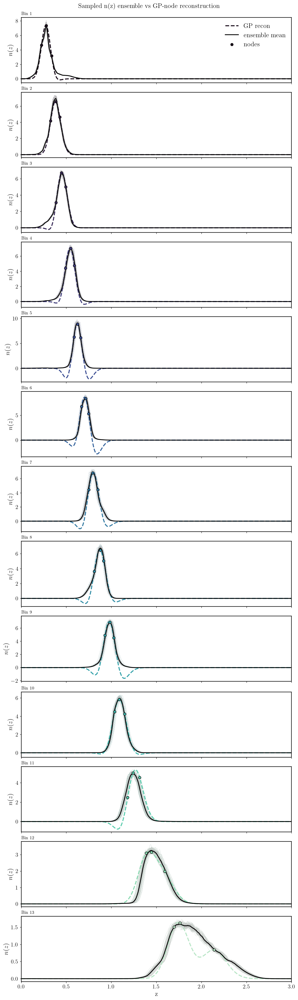

In [10]:
palette = sns.color_palette("mako", len(priors))

n_bins = len(priors)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax = axes[b]

    arr = nz_ensemble_list[b]

    # --- Original ensemble (thin dashed)
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax.plot(z_grid, nz_i,
                color=palette[b],
                alpha=0.15, lw=1, ls="--")
        

    # --- Ensemble curves (solid, translucent)
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.3, lw=0.8)

    # --- GP reconstruction
    ax.plot(z_grid, nz_recon[b],
            color=palette[b], ls='--', lw=2.5, label="GP recon")

    # --- Ensemble mean
    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")

    # --- Node locations
    z_nodes = priors[b]["z_nodes"]
    ax.scatter(z_nodes, theta_all_bins[b],
               s=40, color=palette[b],
               edgecolor="black", zorder=5,
               label="nodes")

    ax.set_ylabel(r"$n(z)$")
    
    ax.set_title(f"Bin {b+1}", loc="left", fontsize=11)
    ax.set_xlim(0, 3)

# Legend only once
axes[0].legend(frameon=False, fontsize=16)

axes[-1].set_xlabel("z")
fig.suptitle("Sampled n(z) ensemble vs GP-node reconstruction", fontsize=16)
#plt.savefig("/home/jipdebuck/plots/new_reconst.png", dpi=600)

### 3. Enforcing positivity by going to log space, while enforcing going to zero at the edges with window function

In [11]:
# Redefining the way we reconstruct n(z) to enforce positivity # 

def window_func(x):
    """
    Window function to ensure positivity.
    The form of this function is up to the user.
    """
    return x*(1-x)

def reconstruct_nz_from_nodes_gp_pos(
    z_pred,
    z_nodes,
    theta_nodes,
    window,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,          # <-- optional like your example
):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)

    # training data (anchors)
    z_train = np.asarray(z_nodes, float)
    y_train = np.asarray(theta_nodes, float)

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)
    w_pred = window(X_pred.ravel())

    # applying window function
    w_train = window(X_train.ravel())
    y_train_log = np.log(y_train/w_train)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_log)

    if return_std:
        y_pred_log, y_std = gp.predict(X_pred, return_std=True)
        y_pred = w_pred*np.exp(y_pred_log)
        return y_pred, y_std, gp
    else:
        y_pred_log = gp.predict(X_pred, return_std=False)
        y_pred = w_pred*np.exp(y_pred_log)
        return y_pred
    
def reconstruct_all_bins_pos(
    z_pred,
    priors,
    theta_all_bins,            # list of arrays, each shape (M,)
    window,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = []
    for b, pb in enumerate(priors):
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp_pos(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                window=window,
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True,
            )
            out.append((mean, std))
        else:
            nz = reconstruct_nz_from_nodes_gp_pos(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                window=window,
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False,
            )
            out.append(nz)
    return out
    
priors = build_gp_node_priors_per_bin(
    z=z_grid,
    nz_ensemble_list=nz_ensemble_list,
    z_bounds=(0.0, 3.0),
    quantiles=(0.2, 0.5, 0.8),  # 3 nodes per bin (tune to 2–5)
)
rng = np.random.default_rng(42)

theta_all_bins = []
for b, pb in enumerate(priors):
    mu = pb["mu"]        # shape (M,)
    Sigma = pb["Sigma"]  # shape (M, M)
    theta_b = rng.multivariate_normal(mu, Sigma)
    theta_all_bins.append(theta_b)

nz_recon = reconstruct_all_bins_pos(
    z_pred=z_grid,
    priors=priors,
    theta_all_bins=theta_all_bins,
    window=window_func,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,           # <-- crucial for interpolation
)


Text(0.5, 0.98, 'Sampled n(z) ensemble vs GP-node reconstruction')

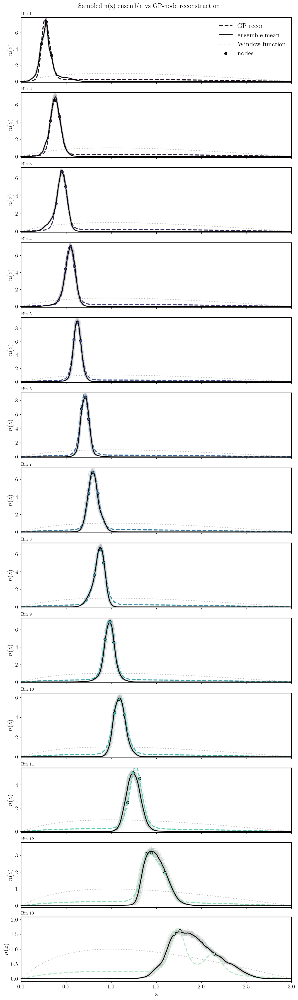

In [12]:
palette = sns.color_palette("mako", len(priors))

n_bins = len(priors)

x_grid = x_log1p(z_grid, 3)
w_grid = window_func(x_grid)
w_grid_norm = w_grid/np.max(w_grid)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax = axes[b]

    arr = nz_ensemble_list[b]

    # --- Original ensemble (thin dashed)
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax.plot(z_grid, nz_i,
                color=palette[b],
                alpha=0.15, lw=1, ls="--")
        

    # --- Ensemble curves (solid, translucent)
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.3, lw=0.8)

    # --- GP reconstruction
    ax.plot(z_grid, nz_recon[b],
            color=palette[b], ls='--', lw=2.5, label="GP recon")

    # --- Ensemble mean
    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")
    ax.plot(z_grid, w_grid_norm, color='black', alpha=0.3, linestyle='dotted', label='Window function', zorder=0)
    # --- Node locations
    z_nodes = priors[b]["z_nodes"]
    ax.scatter(z_nodes, theta_all_bins[b],
               s=40, color=palette[b],
               edgecolor="black", zorder=5,
               label="nodes")

    ax.set_ylabel(r"$n(z)$")
    
    ax.set_title(f"Bin {b+1}", loc="left", fontsize=11)
    ax.set_xlim(0, 3)
    ax.set_ylim(-0.1, np.max(nz_mean)+0.5)
# Legend only once
axes[0].legend(frameon=False, fontsize=16)

axes[-1].set_xlabel("z")
fig.suptitle("Sampled n(z) ensemble vs GP-node reconstruction", fontsize=16)

### 4. Enforcing positivity by going to log-space, while enforcing going to zero at edges with training nodes 

In [12]:
# Redefining the way we reconstruct n(z) to enforce positivity # 

def reconstruct_nz_from_nodes_gp_log(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,          # <-- optional like your example
):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)

    # training data (anchors)
    z_train = np.concatenate([[zmin], np.asarray(z_nodes, float), [zmax]])
    y_train = np.concatenate([[1e-7], np.asarray(theta_nodes, float), [1e-7]])

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)

    y_train_log = np.log(y_train)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_log)

    if return_std:
        y_pred_log, y_std = gp.predict(X_pred, return_std=True)
        y_pred = np.exp(y_pred_log)
        return y_pred, y_std, gp
    else:
        y_pred_log = gp.predict(X_pred, return_std=False)
        y_pred = np.exp(y_pred_log)
        return y_pred
    
def reconstruct_all_bins_log(
    z_pred,
    priors,
    theta_all_bins,            # list of arrays, each shape (M,)
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = []
    for b, pb in enumerate(priors):
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp_log(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True,
            )
            out.append((mean, std))
        else:
            nz = reconstruct_nz_from_nodes_gp_log(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False,
            )
            out.append(nz)
    return out
    
priors = build_gp_node_priors_per_bin(
    z=z_grid,
    nz_ensemble_list=nz_ensemble_list,
    z_bounds=(0.0, 3.0),
    quantiles=(0.2, 0.5, 0.8),  # 3 nodes per bin (tune to 2–5)
)
rng = np.random.default_rng(42)

theta_all_bins = []
for b, pb in enumerate(priors):
    mu = pb["mu"]        # shape (M,)
    Sigma = pb["Sigma"]  # shape (M, M)
    theta_b = rng.multivariate_normal(mu, Sigma)
    theta_all_bins.append(theta_b)

nz_recon = reconstruct_all_bins_log(
    z_pred=z_grid,
    priors=priors,
    theta_all_bins=theta_all_bins,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,           # <-- crucial for interpolation
)


Text(0.5, 0.98, 'Sampled n(z) ensemble vs GP-node reconstruction')

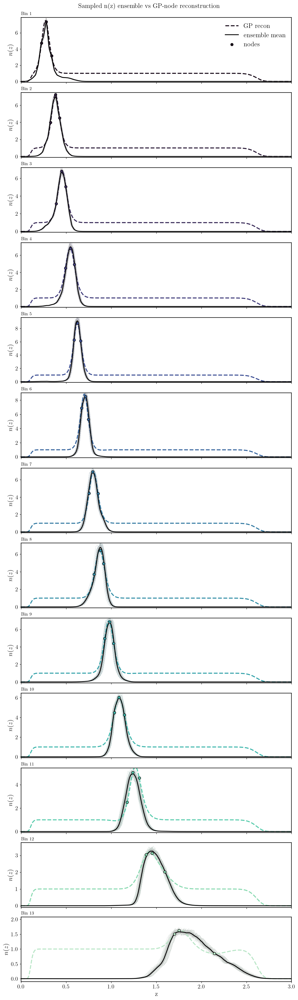

In [13]:
palette = sns.color_palette("mako", len(priors))

n_bins = len(priors)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax = axes[b]

    arr = nz_ensemble_list[b]

    # --- Original ensemble (thin dashed)
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax.plot(z_grid, nz_i,
                color=palette[b],
                alpha=0.15, lw=1, ls="--")
        

    # --- Ensemble curves (solid, translucent)
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.3, lw=0.8)

    # --- GP reconstruction
    ax.plot(z_grid, nz_recon[b],
            color=palette[b], ls='--', lw=2.5, label="GP recon")

    # --- Ensemble mean
    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")
    
    # --- Node locations
    z_nodes = priors[b]["z_nodes"]
    ax.scatter(z_nodes, theta_all_bins[b],
               s=40, color=palette[b],
               edgecolor="black", zorder=5,
               label="nodes")

    ax.set_ylabel(r"$n(z)$")
    
    ax.set_title(f"Bin {b+1}", loc="left", fontsize=11)
    ax.set_xlim(0, 3)
    ax.set_ylim(-0.1, np.max(nz_mean)+0.5)
# Legend only once
axes[0].legend(frameon=False, fontsize=16)

axes[-1].set_xlabel("z")
fig.suptitle("Sampled n(z) ensemble vs GP-node reconstruction", fontsize=16)

### 5. Enforcing positivity by going to squared space, while ensuring going to zero with training nodes at edges

In [13]:
def reconstruct_nz_from_nodes_gp_square(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False

):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)
    z_train = np.concatenate([[zmin], np.asarray(z_nodes, float), [zmax]])
    y_train_squareroot = np.concatenate([[0], np.asarray(np.sqrt(theta_nodes), float), [0]])

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_squareroot)

    if return_std:
        y_pred_squareroot, y_std = gp.predict(X_pred, return_std=True)
        y_pred = y_pred_squareroot**2
        return y_pred, y_std, gp
    else:
        y_pred_squareroot = gp.predict(X_pred, return_std=False)
        y_pred = y_pred_squareroot**2
        return y_pred

def reconstruct_all_bins_square(
    z_pred,
    priors,
    theta_all_bins,            # list of arrays, each shape (M,)
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = []
    for b, pb in enumerate(priors):
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True
            )
            out.append((mean, std))
        else:
            nz = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=pb["z_nodes"],
                theta_nodes=theta_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False
            )
            out.append(nz)
    return out
    
priors = build_gp_node_priors_per_bin(
    z=z_grid,
    nz_ensemble_list=nz_ensemble_list,
    z_bounds=(0.0, 3.0),
    quantiles=(0.2, 0.5, 0.8),  # 3 nodes per bin (tune to 2–5)
)
rng = np.random.default_rng(42)

theta_all_bins = []
for b, pb in enumerate(priors):
    mu = pb["mu"]        # shape (M,)
    Sigma = pb["Sigma"]  # shape (M, M)
    theta_b = rng.multivariate_normal(mu, Sigma)
    theta_all_bins.append(theta_b)

z_left_list = [0.1, 0.3, 0.5, 0.7, 0.7, 1]
z_right_list = [1.5, 1.7, 1.5, 1.8, 2.1, 3]

nz_recon = reconstruct_all_bins_square(
    z_pred=z_grid,
    priors=priors,
    theta_all_bins=theta_all_bins,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0         # <-- crucial for interpolation
)


Text(0.5, 0.98, 'Sampled n(z) ensemble vs GP-node reconstruction')

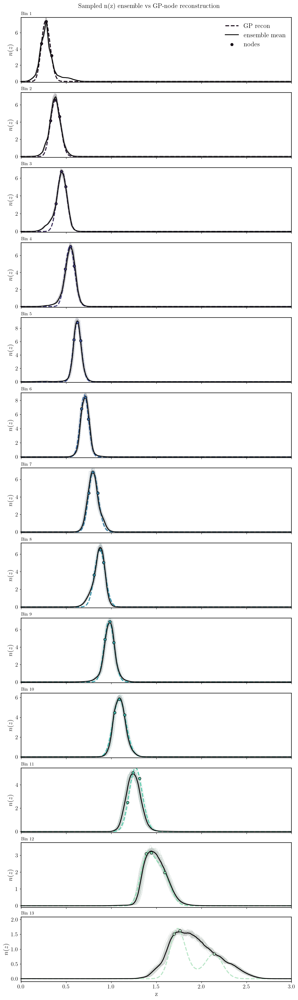

In [14]:
palette = sns.color_palette("mako", len(priors))

n_bins = len(priors)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax = axes[b]

    arr = nz_ensemble_list[b]

    # --- Original ensemble (thin dashed)
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax.plot(z_grid, nz_i,
                color=palette[b],
                alpha=0.15, lw=1, ls="--")
        

    # --- Ensemble curves (solid, translucent)
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.3, lw=0.8)

    # --- GP reconstruction
    ax.plot(z_grid, nz_recon[b],
            color=palette[b], ls='--', lw=2.5, label="GP recon")

    # --- Ensemble mean
    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")
    
    # --- Node locations
    z_nodes = priors[b]["z_nodes"]
    ax.scatter(z_nodes, theta_all_bins[b],
               s=40, color=palette[b],
               edgecolor="black", zorder=5,
               label="nodes")

    ax.set_ylabel(r"$n(z)$")
    
    ax.set_title(f"Bin {b+1}", loc="left", fontsize=11)
    ax.set_xlim(0, 3)
    ax.set_ylim(-0.1, np.max(nz_mean)+0.5)
# Legend only once
axes[0].legend(frameon=False, fontsize=16)

axes[-1].set_xlabel("z")
fig.suptitle("Sampled n(z) ensemble vs GP-node reconstruction", fontsize=16)

### 6. Implementing the prior for DR1, i.e. 13 --> 6 bins

In [15]:
# Load in the DR1 n(z) 
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

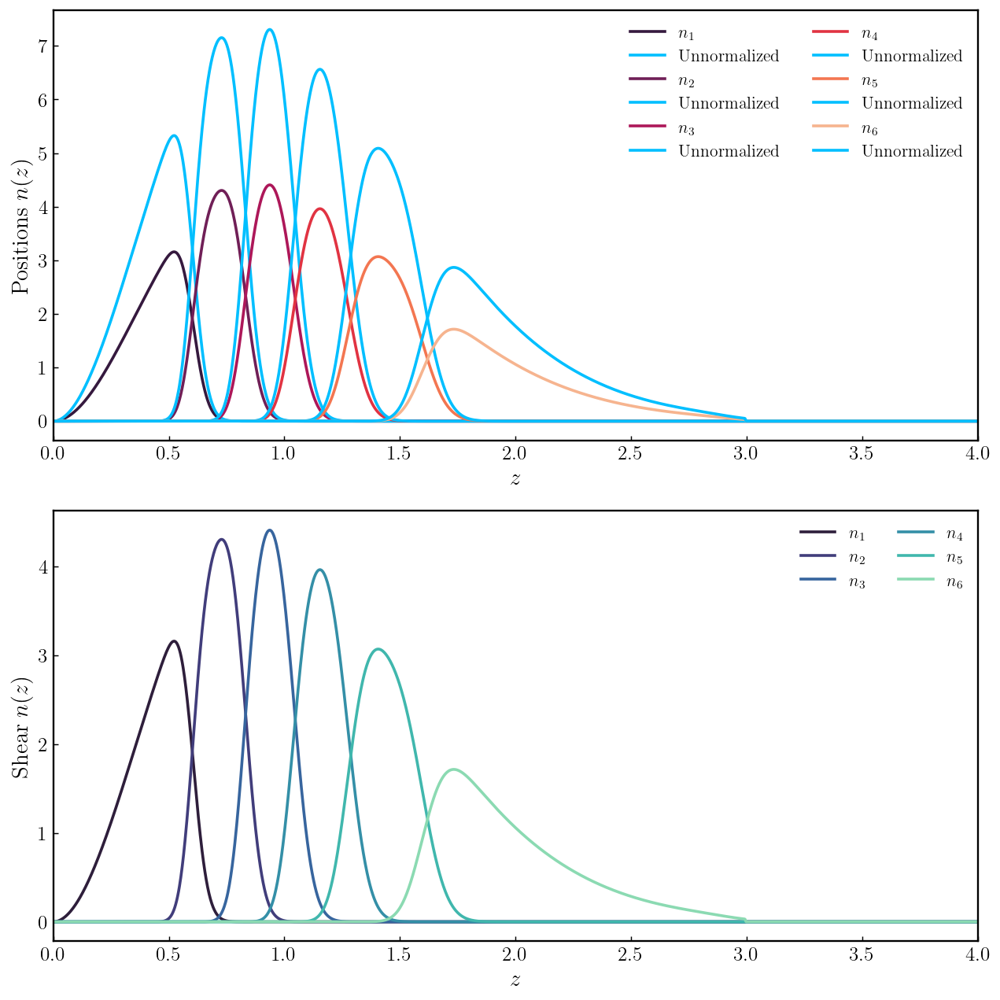

In [16]:
# Plotting of original n(z) distributions #

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)
    axs[0].plot(z_nz, nz_heracles[key], color='deepskyblue', linewidth=2, label='Unnormalized')

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [17]:
# Define parameters for GP reconstruction #

z_meds = []   # positions of median redshift for each bin
n_meds = []   # height of n(z) at median redshift for each bin

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z)
    n_med = nz[np.argmin(np.abs(z - z_med))]
    z_meds.append(z_med)
    n_meds.append(n_med)

corr_len = 0.03                                # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude

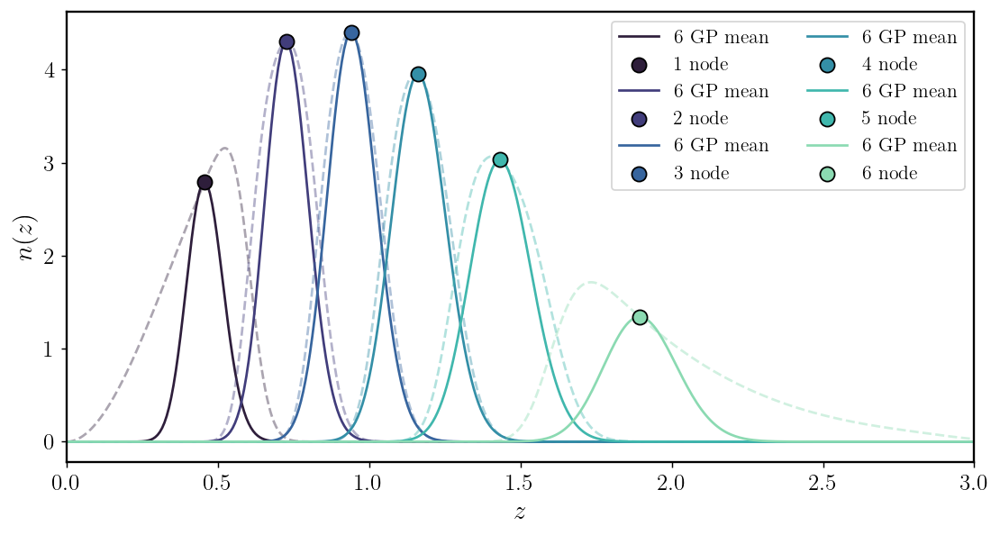

In [18]:
# GP reconstruction and plotting of results #

# Perform GP reconstruction #
priors, predictions = build_gp_nz(n_meds, z_meds, corr_len, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)

# Plot GP reconstruction results #
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    #ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
    #                color=palette[j], alpha=0.2)

    ax.plot(z, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()

In [19]:
# Creating a list of plausible n(z) realizations

z_ens_list, nz_ensemble_list = zip(*[
    generate_bin1_ensemble(
        N_ens=50, 
        nz=dndz_she_norm[i], 
        N_z=3001,
        mean_shift_sigma=0.03,
        width_shift_sigma=0.04,
        shape_noise_sigma=0.1
    )
    for i in range(1, 7)
])

In [20]:
# Computing relative widths of bins 

x_grid = x_log1p(z_grid, 3)

widths = []

for arr in nz_ensemble_list:
    nz_norm = arr / np.trapezoid(arr, z_grid, axis=1)[:, None]
    nz_mean = np.mean(nz_norm, axis=0)
    p = nz_mean / np.trapezoid(nz_mean, x_grid)
    mean_x = np.trapezoid(x_grid * p, x_grid)
    var_x  = np.trapezoid((x_grid - mean_x)**2 * p, x_grid)
    sigma_x = np.sqrt(var_x)
    widths.append(sigma_x)
    
widths = np.array(widths)
rel_widths = widths / widths[0]
print(rel_widths)

[1.         0.51648615 0.47315338 0.47883908 0.53323591 0.99196652]


In [22]:
# Building the prior for the heights of the training nodes from the n(z) ensemble

priors = build_gp_node_priors_per_bin(
    z=z_grid,
    nz_ensemble_list=nz_ensemble_list,
    z_bounds=(0.0, 3.0),
    quantiles=(0.1, 0.5, 0.9),  # 3 nodes per bin (tune to 2–5)
)

rng = np.random.default_rng(42)

theta_all_bins = []
for b, pb in enumerate(priors):
    mu = pb["mu"]        # shape (M,)
    Sigma = pb["Sigma"]  # shape (M, M)
    theta_b = rng.multivariate_normal(mu, Sigma)
    theta_all_bins.append(theta_b)

nz_recon = reconstruct_all_bins_square(
    z_pred=z_grid,
    priors=priors,
    theta_all_bins=theta_all_bins,
    z_bounds=(0.0, 3.0),
    corr_len=0.065,
    amp=0.04,
    alpha=0.0,           
)

Text(0.5, 0.98, 'Sampled n(z) ensemble vs GP-node reconstruction')

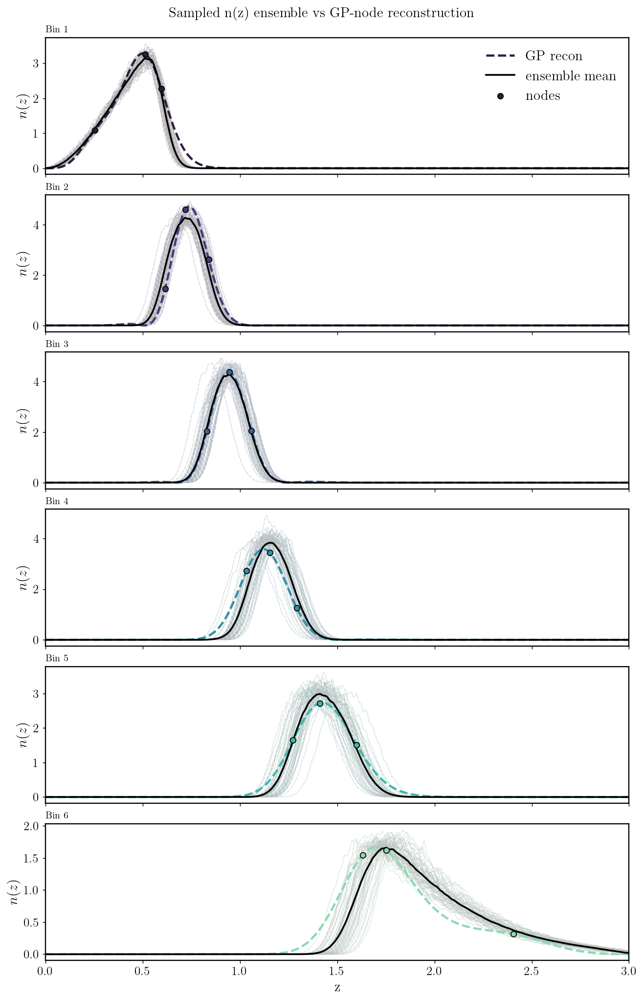

In [23]:
# Plotting the reconstructions per bin

palette = sns.color_palette("mako", len(priors))

n_bins = len(priors)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax = axes[b]
    arr = nz_ensemble_list[b]
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax.plot(z_grid, nz_i,
                color=palette[b],
                alpha=0.15, lw=1, ls="--")
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.3, lw=0.8)
    ax.plot(z_grid, nz_recon[b],
            color=palette[b], ls='--', lw=2.5, label="GP recon")
    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")
    z_nodes = priors[b]["z_nodes"]
    ax.scatter(z_nodes, theta_all_bins[b],
               s=40, color=palette[b],
               edgecolor="black", zorder=5,
               label="nodes")

    ax.set_ylabel(r"$n(z)$")
    
    ax.set_title(f"Bin {b+1}", loc="left", fontsize=11)
    ax.set_xlim(0, 3)

# Legend only once
axes[0].legend(frameon=False, fontsize=16)

axes[-1].set_xlabel("z")
fig.suptitle("Sampled n(z) ensemble vs GP-node reconstruction", fontsize=16)
#plt.savefig("/home/jipdebuck/plots/new_reconst.png", dpi=600)

In [24]:
n_samples = 50
rng = np.random.default_rng(42)

# Store GP reconstructions per bin
gp_samples_per_bin = []

for b, pb in enumerate(priors):
    mu = pb["mu"]        # (M,)
    Sigma = pb["Sigma"]  # (M, M)
    theta_samples = rng.multivariate_normal(mu, Sigma, size=n_samples) # draw 50 samples of GP nodes
    theta_samples = np.clip(theta_samples, 1e-6, None)
    corr_lens = rng.uniform(0.05, 0.09, size=n_samples) # draw 50 correlation lengths
    curves = []
    for s in range(n_samples):
        nz_s = reconstruct_all_bins_square(
            z_pred=z_grid,
            priors=priors,
            theta_all_bins=[
                theta_samples[s] if i == b else theta_all_bins[i]
                for i in range(len(priors))
            ],
            z_bounds=(0.0, 3.0),
            corr_len=corr_lens[s],  
            amp=0.04,
            alpha=0.0,
        )[b]
        curves.append(nz_s)

    gp_samples_per_bin.append(np.array(curves))

Text(0.5, 0.98, 'GP prior samples (left) vs original ensemble (right)')

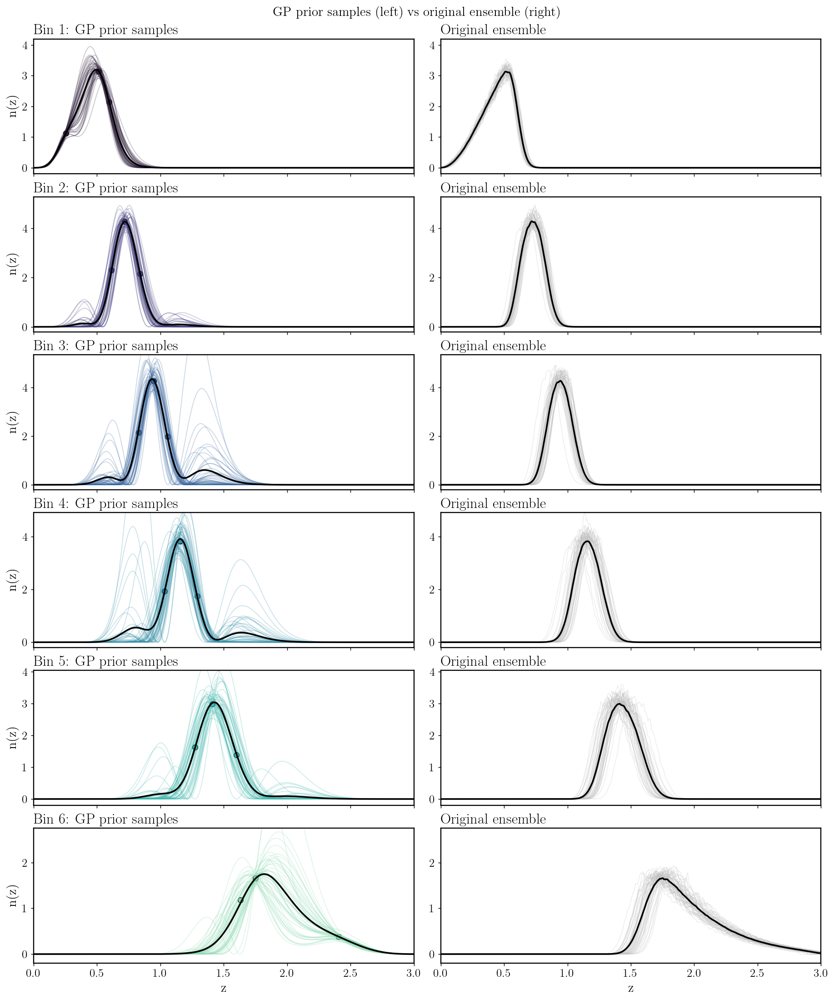

In [25]:
palette = sns.color_palette("mako", len(priors))
n_bins = len(priors)

fig, axes = plt.subplots(
    n_bins, 2,
    figsize=(14, 2.8 * n_bins),
    sharex=True,
    constrained_layout=True
)

for b in range(n_bins):
    ax_left  = axes[b, 0]
    ax_right = axes[b, 1]

    arr = nz_ensemble_list[b]
    gp_curves = gp_samples_per_bin[b]
    for i in range(gp_curves.shape[0]):
        ax_left.plot(z_grid, gp_curves[i],
                     color=palette[b], alpha=0.25, lw=1)

    # Mean of GP samples
    ax_left.plot(z_grid, gp_curves.mean(axis=0),
                 color="black", lw=2, label="GP mean")

    # Node locations (mean)
    z_nodes = priors[b]["z_nodes"]
    ax_left.scatter(z_nodes, priors[b]["mu"],
                    s=40, color=palette[b], edgecolor="black")

    ax_left.set_title(f"Bin {b+1}: GP prior samples", loc="left")
    ax_left.set_ylabel("n(z)")
    ax_left.set_xlim(0, 3)
    ax_left.set_ylim(-0.2, max(gp_curves.mean(axis=0))+1)
    for i in range(arr.shape[0]):
        nz_i = arr[i] / np.trapezoid(arr[i], z_grid)
        ax_right.plot(z_grid, nz_i,
                      color="silver", alpha=0.3, lw=0.8)

    nz_mean = np.mean(
        arr / np.trapezoid(arr, z_grid, axis=1)[:, None],
        axis=0
    )
    ax_right.plot(z_grid, nz_mean, color="black", lw=2, label="ensemble mean")

    ax_right.set_title("Original ensemble", loc="left")
    ax_right.set_xlim(0, 3)
    ax_right.set_ylim(-0.2, max(gp_curves.mean(axis=0))+1)

axes[-1, 0].set_xlabel("z")
axes[-1, 1].set_xlabel("z")

fig.suptitle("GP prior samples (left) vs original ensemble (right)", fontsize=16)

### 7. Using Kernel Density Estimation (KDE) to estimate the 2D density of the ensemble 

Reconstructing for bin 1
Reconstructing for bin 2
Reconstructing for bin 3
Reconstructing for bin 4
Reconstructing for bin 5
Reconstructing for bin 6
Reconstructing for bin 7
Reconstructing for bin 8
Reconstructing for bin 9
Reconstructing for bin 10
Reconstructing for bin 11
Reconstructing for bin 12
Reconstructing for bin 13


(0.183, 0.221)

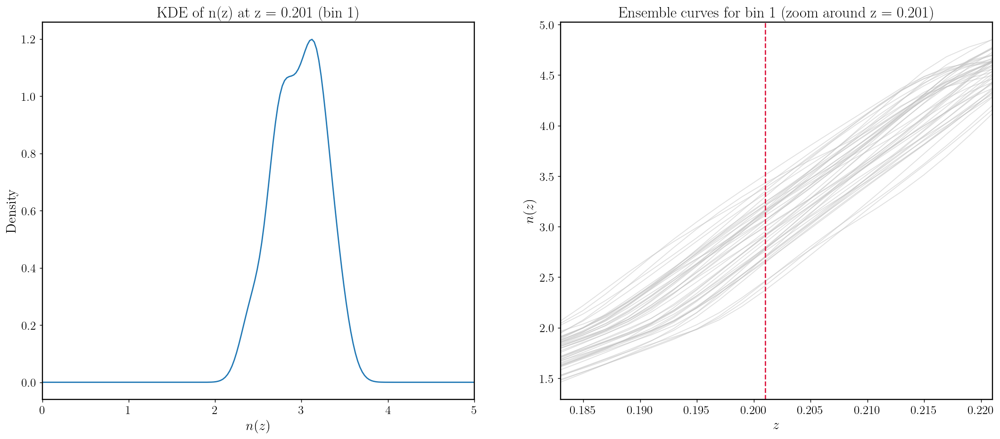

In [18]:
def compute_1d_kdes_for_bin(z, ensemble):
    N_ens, N_z = ensemble.shape
    kdes = []
    for j in range(N_z):
        samples = ensemble[:, j]          # the 50 ensemble values at this specific z
        kde = gaussian_kde(samples)       #compute the KDE at this specific z using the 50 values 
        kdes.append(kde) #we get a KDE for each redshift z in the given bin
    return kdes


kde_1d_bins = []

for b in range(13):
    print(f"Reconstructing for bin {b+1}")
    z = z_ens_list[b]                     
    ensemble = nz_ensemble_list[b]        
    kdes = compute_1d_kdes_for_bin(z, ensemble) # computing the KDE in a specific bin
    kde_1d_bins.append((z, kdes))


bin_index = 0
z, kdes = kde_1d_bins[bin_index] # kdes for first bin evaluated at each redshift in the first bin

j = 100  # one specific redshift 
kde = kdes[j]

# Evaluate density on a y-grid
y_grid = np.linspace(0, nz_ensemble_list[bin_index][:, j].max()*1.5, 200) 
density = kde(y_grid)


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].plot(y_grid, density)
axes[0].set_title(f"KDE of n(z) at z = {z[j]:.3f} (bin {bin_index+1})")
axes[0].set_xlim(0,5)
axes[0].set_xlabel("$n(z)$")
axes[0].set_ylabel("Density")


# Choose zoom center and width
z0 = 0.201
dz = 0.02

# Mask for zoom window
mask = (z_ens_list[0] > z0 - dz) & (z_ens_list[0] < z0 + dz)

for i in range(nz_ensemble_list[0].shape[0]):
    axes[1].plot(
        z_ens_list[0][mask],
        nz_ensemble_list[0][i][mask] / np.trapezoid(nz_ensemble_list[0][i], z_ens_list[0]),
        color="silver", alpha=0.5, lw=1
    )
axes[1].axvline(z0, color='crimson', lw=1.5, linestyle='--', label=f"$z$ = {z0}")
axes[1].set_title(f"Ensemble curves for bin 1 (zoom around z = {z0:.3f})")
axes[1].set_xlabel("$z$")
axes[1].set_ylabel("$n(z)$")
axes[1].set_xlim(0.183, z0 + dz)




### 8. Determine the prior on the y nodes using normalizing flows 

In [38]:
def generate_bin1_ensemble_unnorm(
    N_ens=5,
    z_lo=0.001,
    z_hi=6,
    N_z=3001,
    mean_shift_sigma=0.01,
    width_shift_sigma=0.02,
    shape_noise_sigma=0.07,
    smooth_scale=3,
    nz = dndz_she_norm[1]
):
    """
    Generate an ensemble of n(z) realisations for the FIRST bin only:
        z ∈ [0.001, 0.42]
    using small shifts + smooth perturbations.
    """

    # ---------------------------
    # 1. Grid + base bin n(z)
    # ---------------------------
    z = np.linspace(z_lo, z_hi, N_z)
#    nz /= np.trapezoid(nz, z)        # ensure norm within [0, 3] part
    nz_bin = nz.copy()               # for first bin, that's it

    # ---------------------------
    # Build ensemble
    # ---------------------------
    ensemble = []

    z_mean = np.trapezoid(z * nz_bin, z)

    for _ in range(N_ens):

        # Mean shift
        dz = np.random.normal(0, mean_shift_sigma) * z_mean
        z_shift = np.clip(z + dz, z_lo, z_hi)

        # Width/stretch shift
        width = 1 + np.random.normal(0, width_shift_sigma)
        z_stretch = z_mean + width * (z_shift - z_mean)
        z_stretch = np.clip(z_stretch, z_lo, z_hi)

        # Smooth random shape fluctuation
        noise = np.random.normal(0, shape_noise_sigma, N_z)
        noise_smooth = gaussian_filter1d(noise, smooth_scale)
        nz_pert = nz_bin * (1 + noise_smooth)
        nz_pert = np.clip(nz_pert, 1e-12, None)

        # Interpolate to shifted grid
        nz_new = np.interp(z, z_stretch, nz_pert, left=0, right=0)

        # Normalise inside the bin
#        nz_new /= np.trapezoid(nz_new, z)

        ensemble.append(nz_new)

    return z, np.array(ensemble)


In [80]:
z_ens_list_unnorm, nz_ensemble_list_unnorm = zip(*[
    generate_bin1_ensemble_unnorm(
        N_ens=50, 
        nz=nz_heracles[i], 
        N_z=3001,
        mean_shift_sigma=0.01,
        width_shift_sigma=0.02,
        shape_noise_sigma=0.07
    )
    for i in range(1, 7)
])

In [41]:
# Defining function to determine training data for normalizing flow from CDF

def compute_cdf_nodes_per_bin(z_grid, nz_ens, M=5, qmin=0.05, qmax=0.95):
    nz_mean = nz_ens.mean(axis=0)
#    nz_mean /= np.trapezoid(nz_mean, z_grid) # normalized mean of ensemble
    cdf = integrate.cumulative_trapezoid(nz_mean, z_grid, initial=0) # cdf of ensemble mean
    cdf /= cdf[-1]
    quantiles = np.linspace(qmin, qmax, M)
    x_nodes = np.interp(quantiles, cdf, z_grid) # x nodes at given quantiles
    Y_nodes = []
    for k in range(nz_ens.shape[0]):
        nz_k = nz_ens[k] 
        y_k = np.interp(x_nodes, z_grid, nz_k)
        Y_nodes.append(y_k)
    Y_nodes = np.stack(Y_nodes, axis=0)  # shape: (N_ens, M) 
    return x_nodes, Y_nodes


In [83]:
# Determining training data for each bin using previously defined function

x_nodes_list_unnorm = []
Y_nodes_list_unnorm = []

for b in range(len(nz_ensemble_list_unnorm)):
    nz_ens = nz_ensemble_list_unnorm[b]     
    z_grid = z_ens_list_unnorm[b]           

    x_nodes_unnorm, Y_nodes_unnorm = compute_cdf_nodes_per_bin(z_grid, nz_ens, M=5)

    x_nodes_list_unnorm.append(x_nodes_unnorm)
    Y_nodes_list_unnorm.append(Y_nodes_unnorm)


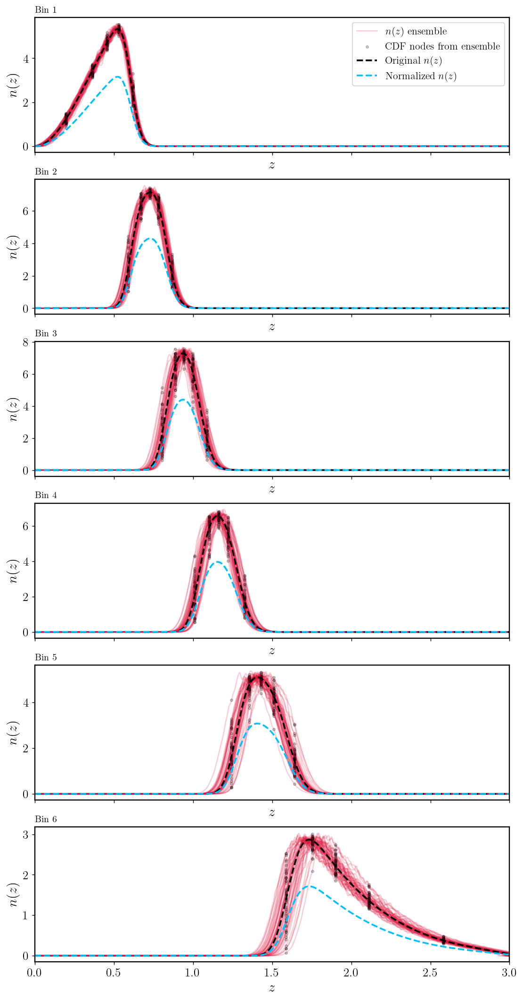

In [84]:
# Plotting training data for each bin

z_grid = z_ens_list_unnorm[0]

fig, axes = plt.subplots(6, 1, figsize=(10,20), sharex=True)
axes = axes.flatten()
for i in range(len(nz_ensemble_list_unnorm)):
    nz_ens = nz_ensemble_list_unnorm[i]
    for j, nz in enumerate(nz_ens):
        if i == 0 and j == 0:
            axes[i].plot(z_grid, nz, color='crimson', alpha=0.2, label='$n(z)$ ensemble')
            axes[i].scatter(x_nodes_list[i], Y_nodes_list[i][j], marker='.', color='black', alpha=0.2, zorder=2, label='CDF nodes from ensemble')
        else:
            axes[i].plot(z_grid, nz, color='crimson', alpha=0.2)
            axes[i].scatter(x_nodes_list[i], Y_nodes_list[i][j], marker='.', color='black', alpha=0.2, zorder=2)
        
    axes[i].set_xlim(0, 3)
    axes[i].set_title(f"Bin {i+1}", loc="left", fontsize=11)
    axes[i].set_xlabel("$z$")
    axes[i].set_ylabel("$n(z)$")
    axes[i].plot(z_nz, nz_heracles[i+1], linestyle='--', lw=2, c='black', label='Original $n(z)$')
    axes[i].plot(z_nz, dndz_she_norm[i+1], linestyle='--', lw=2, c='deepskyblue', label='Normalized $n(z)$')
axes[0].legend()


In [57]:
# Defining a function that trains the normalizing flow on the training data 
from tqdm import tqdm
import torch 
from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import CompositeTransform, MaskedAffineAutoregressiveTransform

def normalizing_flow_per_bin(Y_nodes, n_layers=5, hidden_features=64, lr=1e-3, steps=3000):
    # normalizing flow = invertible neural network that learns a probability distribution
    eps = 1e-6
    U = np.log(np.clip(Y_nodes, eps, None))

    # standardize the log-values
    mean = U.mean(axis=0)
    std = U.std(axis=0) + 1e-6
    U_norm = (U - mean) / std

    M = U_norm.shape[1]
    base = StandardNormal(shape=[M])  # all flows begin as standard Gaussian vectors

    transforms = []  # here, invertible transformations will be stored
    for _ in range(n_layers):  # autoregressive layers
        transforms.append(
            MaskedAffineAutoregressiveTransform(
                features=M,
                hidden_features=hidden_features  # small neural network inside each layer
            )
        )  # here, each layer learns a transformation

    transform = CompositeTransform(transforms)  # combine layers into a single transformation
    flow = Flow(transform, base)  # start with Gaussian base and apply transformation to get log_prob(y)

    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)  # optimize flow with Adam
    data = torch.tensor(U_norm, dtype=torch.float32)

    # training loop
    for step in tqdm(range(steps), desc="Training flow", ncols=80):
        idx = torch.randint(0, data.shape[0], (128,))  # randomly selects 128 indices (minibatch)
        batch = data[idx]
        loss = -flow.log_prob(batch).mean()  # negative log likelihood is computed
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()  # flow parameters are updated according to negative log likelihood
    
    return flow, mean, std

In [85]:
flows_unnorm = []
means_unnorm = []
stds_unnorm = []

for b in range(len(Y_nodes_list_unnorm)):
    print(f"Training flow for bin {b+1}")
    flow_b, mean_b, std_b = normalizing_flow_per_bin(Y_nodes_list_unnorm[b])
    flows_unnorm.append(flow_b)
    means_unnorm.append(mean_b)
    stds_unnorm.append(std_b)

Training flow for bin 1


Training flow:   0%|                                   | 0/3000 [00:00<?, ?it/s]/home/jipdebuck/miniconda3/envs/cloe_env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Training flow: 100%|███████████████████████| 3000/3000 [00:23<00:00, 129.83it/s]


Training flow for bin 2


Training flow: 100%|███████████████████████| 3000/3000 [00:20<00:00, 150.00it/s]


Training flow for bin 3


...

Training flow: 100%|███████████████████████| 3000/3000 [00:21<00:00, 136.82it/s]


Training flow for bin 5


Training flow: 100%|███████████████████████| 3000/3000 [00:21<00:00, 142.82it/s]


Training flow for bin 6


Training flow: 100%|███████████████████████| 3000/3000 [00:23<00:00, 129.77it/s]


In [28]:
for b, flow in enumerate(flows_unnorm):
    torch.save(flow.state_dict(), f"/home/jipdebuck/flows_unnorm/flow_bin{b+1}.pt")
    np.save(f"/home/jipdebuck/flows_unnorm/flow_mean_bin{b+1}.npy", means_unnorm[b])
    np.save(f"/home/jipdebuck/flows_unnorm/flow_std_bin{b+1}.npy", stds_unnorm[b])


NameError: name 'flows_unnorm' is not defined

In [59]:
def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key]/integrate.trapezoid(gp_predictions[key], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm


In [66]:
def plot_all_bins(flows, means, stds, x_nodes_list, Y_nodes_list,
                  nz_ensemble_list, z_ens_list,
                  z_pred, reconstruct_nz_from_nodes_gp_square):
    fig, axes = plt.subplots(len(flows), 2, figsize=(22, 4*len(flows)))
    for b in range(len(flows)):
        flow = flows[b]
        mean = means[b]
        std = stds[b]
        x_nodes = x_nodes_list[b]
        Y_nodes = Y_nodes_list[b]
        nz_ens = nz_ensemble_list[b]
        z_grid = z_ens_list[b]

        ax_left = axes[b, 0]
        ax_right = axes[b, 1]
        U_flow_norm = flow.sample(50).detach().numpy()
        U_flow = U_flow_norm * std + mean
        U_flow = np.clip(U_flow, -20, 20)
        Y_flow = np.exp(U_flow)

        for i, y in enumerate(Y_flow):
            y_pred = reconstruct_nz_from_nodes_gp_square(
                z_pred,
                x_nodes,
                y,
                z_bounds=(0.0, 3.0),
                corr_len=0.035,
                amp=0.04,
                alpha=0.0,  # <-- set 0 for interpolation
                kernel_class=RBF,
                nu=1.5,
                return_std=False,
            )
            ax_left.plot(z_pred, y_pred, color="crimson", alpha=0.2)
            z_pred_res = z_pred.reshape(-1, 1)
            y_norm = resample_dndz_gp({"1": y_pred}, z_pred_res, zs)
            if i == 0:
                ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2, label='Nodes sampled from flow')
                ax_left.plot(zs, y_norm[0], color='deepskyblue', alpha=0.5, label='Normalized and resampled predictions')
            else:
                ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2)
                ax_left.plot(zs, y_norm[0], color='deepskyblue', alpha=0.2)
        if min(x_nodes)-0.5 < 0:
            ax_left.set_xlim(0, max(x_nodes)+0.5)
        else:
            ax_left.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
        ax_left.set_title(f"Bin {b+1}: Normalizing Flow Prior Samples")
        ax_left.set_xlabel("$z$")
        ax_left.set_ylabel("$n(z)$")
        ax_left.set_ylim(0, Y_nodes.max()+1)
        ax_left.legend()
        for i in range(nz_ens.shape[0]):
            ax_right.plot(
                z_grid,
                nz_ens[i],
                color="crimson", alpha=0.2, lw=0.8
            )
        for i, nodes in enumerate(Y_nodes):
            if i == 0:
                ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2, label='Nodes from ensemble')
                ax_right.plot(z_grid, nz_ens[i] / np.trapezoid(nz_ens[i], z_grid), color='deepskyblue', alpha=0.2, label='Normalized original')
            else:
                ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2)
                ax_right.plot(z_grid, nz_ens[i] / np.trapezoid(nz_ens[i], z_grid), color='deepskyblue', alpha=0.2)
        if min(x_nodes)-0.5 < 0:
            ax_right.set_xlim(0, max(x_nodes)+0.5)
        else:
            ax_right.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
        ax_right.set_title(f"Bin {b+1}: Ensemble Curves")
        ax_right.set_xlabel("$z$")
        ax_right.set_ylabel("$n(z)$")
        ax_right.set_ylim(0, Y_nodes.max()+1)

    plt.tight_layout()
    return fig

def plot_single_bin(flows, means, stds, x_nodes, Y_nodes,
                  nz_ensemble_list, z_ens_list, corr_len_left, corr_len_right,
                  z_pred, reconstruct_nz_from_nodes_gp_square):
    fig, axes = plt.subplots(1, 2, figsize=(22, 4))
    flow = flows
    mean = means
    std = stds
    nz_ens = nz_ensemble_list
    z_grid = z_ens_list

    ax_left = axes[0]
    ax_right = axes[1]
    U_flow_norm = flow.sample(50).detach().numpy()
    U_flow = U_flow_norm * std + mean
    U_flow = np.clip(U_flow, -20, 20)
    Y_flow = np.exp(U_flow)
    corr_lens = rng.uniform(corr_len_left, corr_len_right, size=len(Y_flow))

    for i, y in enumerate(Y_flow):
        y_pred = reconstruct_nz_from_nodes_gp_square(
                z_pred,
                x_nodes,
                y,
                z_bounds=(0.0, 3.0),
                corr_len=corr_lens[i],
                amp=0.04,
                alpha=0.0,  # <-- set 0 for interpolation
                kernel_class=RBF,
                nu=1.5,
                return_std=False,
            )
        ax_left.plot(z_pred, y_pred, color="crimson", alpha=0.2)
        if i == 0:
            ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2, label='Nodes sampled from flow')
        else:
            ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2)
    if min(x_nodes)-0.5 < 0:
        ax_left.set_xlim(0, max(x_nodes)+0.5)
    else:
        ax_left.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
    ax_left.set_title(f"Normalizing Flow Prior Samples")
    ax_left.set_xlabel("$z$")
    ax_left.set_ylabel("$n(z)$")
    ax_left.set_ylim(0, Y_nodes.max()+1)
    ax_left.legend()
    for i in range(nz_ens.shape[0]):
        ax_right.plot(
                z_grid,
                nz_ens[i],
                color="crimson", alpha=0.2, lw=0.8
            )
    for i, nodes in enumerate(Y_nodes):
        if i == 0:
            ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2, label='Nodes from ensemble')
        else:
            ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2)
    if min(x_nodes)-0.5 < 0:
        ax_right.set_xlim(0, max(x_nodes)+0.5)
    else:
        ax_right.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
    ax_right.set_title(f"Ensemble Curves")
    ax_right.set_xlabel("$z$")
    ax_right.set_ylabel("$n(z)$")
    ax_right.set_ylim(0, Y_nodes.max()+1)

    plt.tight_layout()
    return fig

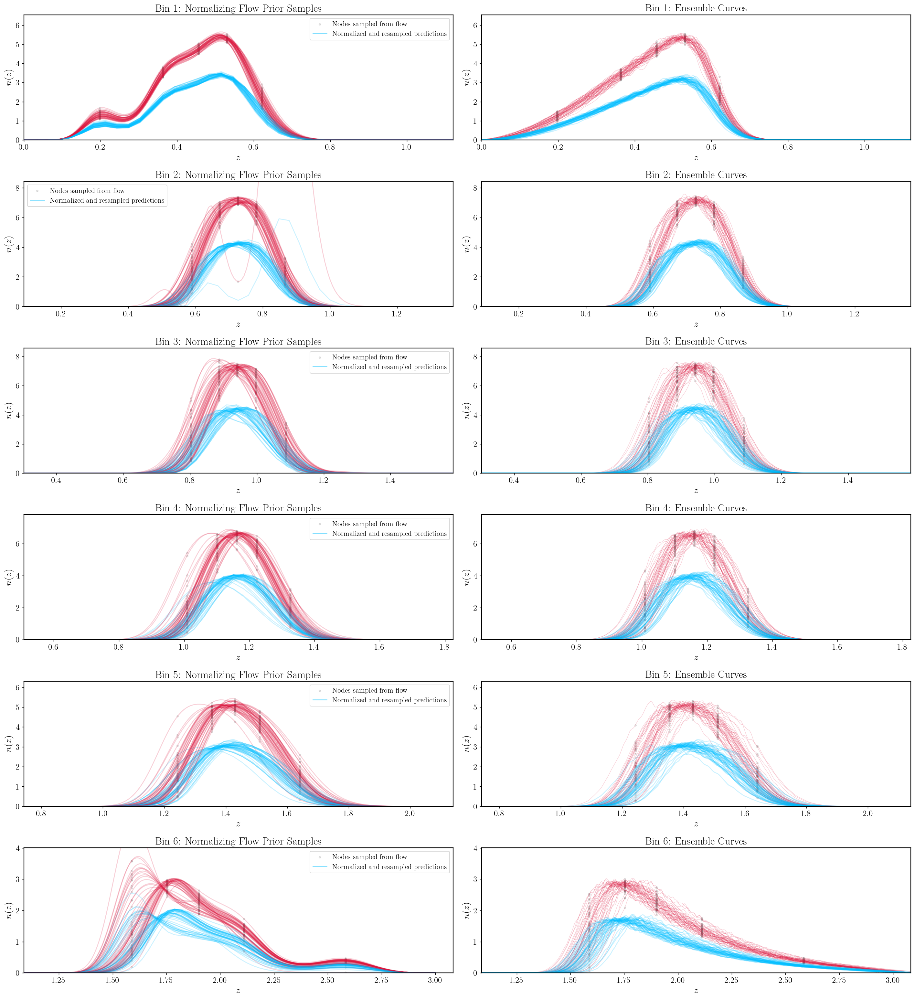

In [99]:
fig = plot_all_bins(
    flows_unnorm, means_unnorm, stds_unnorm,
    x_nodes_list_unnorm, Y_nodes_list_unnorm,
    nz_ensemble_list_unnorm, z_ens_list_unnorm,
    z_pred, reconstruct_nz_from_nodes_gp_square
)

In [103]:
def build_flow(M, n_layers=5, hidden_features=64):
    base = StandardNormal([M])
    transforms = [
        MaskedAffineAutoregressiveTransform(
            features=M,
            hidden_features=hidden_features
        )
        for _ in range(n_layers)
    ]
    transform = CompositeTransform(transforms)
    return Flow(transform, base)
flow_she_bin1 = build_flow(M=5)
flow_she_bin1.load_state_dict(torch.load("/home/jipdebuck/flows_unnorm/flow_bin1.pt", map_location="cpu"))
flow_she_bin1.eval()
flow_mean_she = np.load("/home/jipdebuck/flows_unnorm/flow_mean_bin1.npy")
flow_std_she  = np.load("/home/jipdebuck/flows_unnorm/flow_std_bin1.npy")

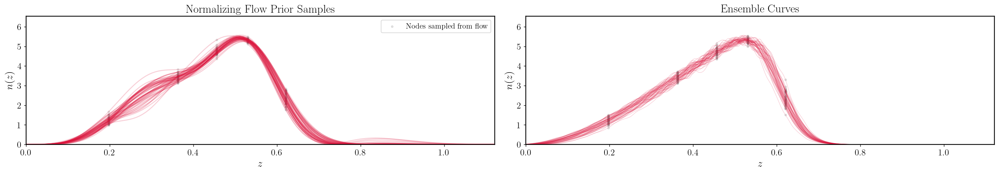

In [115]:


fig = plot_single_bin(
    flow_she_bin1, flow_mean_she, flow_std_she,
    x_nodes_list_unnorm[0], Y_nodes_list_unnorm[0],
    nz_ensemble_list_unnorm[0], z_ens_list_unnorm[0], 0.04, 0.07,
    z_pred, reconstruct_nz_from_nodes_gp_square
)



### 9. Adding the flow as a prior into the chain for a single bin

In [15]:
# Scripts ready to run in Leonardo

import os
os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
#os.environ["MKL_NUM_THREADS"] = "1"
#os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
#os.environ["NUMEXPR_NUM_THREADS"] = "1"


import numpy as np
from scipy import integrate
from multiprocessing import get_context
import time

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, ConstantKernel as C
)

name_to_chain_gp = '3x2pt_LCDM_DR1_flow_bin_1'

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')


# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Find boundaries for x-nodes priors 
def compute_cdf_nodes_per_bin(z_grid, nz_ens, M=5, qmin=0.05, qmax=0.95):
    nz_mean = nz_ens.mean(axis=0)
    nz_mean /= np.trapezoid(nz_mean, z_grid) # normalized mean of ensemble
    cdf = integrate.cumulative_trapezoid(nz_mean, z_grid, initial=0) # cdf of ensemble mean
    cdf /= cdf[-1]
    quantiles = np.linspace(qmin, qmax, M)
    x_nodes = np.interp(quantiles, cdf, z_grid) # x nodes at given quantiles
    Y_nodes = []
    for k in range(nz_ens.shape[0]):
        nz_k = nz_ens[k] / np.trapezoid(nz_ens[k], z_grid)
        y_k = np.interp(x_nodes, z_grid, nz_k)
        Y_nodes.append(y_k)
    Y_nodes = np.stack(Y_nodes, axis=0)  # shape: (N_ens, M) 
    return x_nodes, Y_nodes

nz_ens = nz_ensemble_list[0]     
z_grid = z_ens_list[0]           
x_nodes, Y_nodes = compute_cdf_nodes_per_bin(z_grid, nz_ens, M=5)
print("x_nodes:", x_nodes)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)


def reconstruct_nz_from_nodes_gp_square(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False,          # <-- optional like your example
):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)

    # training data (anchors)
    z_train = np.concatenate([[zmin], np.asarray(z_nodes, float), [zmax]])
    y_train_squareroot = np.concatenate([[0], np.asarray(np.sqrt(theta_nodes), float), [0]])

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_squareroot)

    if return_std:
        y_pred_squareroot, y_std = gp.predict(X_pred, return_std=True)
        y_pred = y_pred_squareroot**2
        return y_pred, y_std, gp
    else:
        y_pred_squareroot = gp.predict(X_pred, return_std=False)
        y_pred = y_pred_squareroot**2
        return y_pred


# Define fixed GP hyperparameters 
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
z_pred_res = z_pred.reshape(-1, 1)


fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 
    # Redshift errors (positions)
    'dz_pos_1': 0.0,
    'width_pos_1': 1.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key]/integrate.trapezoid(gp_predictions[key], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm[0][None, :],
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm[0][None, :],
    z=myz,
    nuisance_params=nuisance_params
)


cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

n_ell = 32
idx_wl  = np.arange(0,        0 + n_ell)      # 0:32
idx_ggl = np.arange(672,      672 + n_ell)    # 672:704
idx_gc  = np.arange(1824,     1824 + n_ell)   # 1824:1856
idx_bin1 = np.concatenate([idx_wl, idx_ggl, idx_gc])
cov_bin1 = full_cov[np.ix_(idx_bin1, idx_bin1)]

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    scale_cuts = {}

    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('POS', 'SHE'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [10, 1500]

    return {
        'n_ell_bins': 32,
        'scale_cuts': scale_cuts
    }

data_3x2pt = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             cov_bin1, 
                             myz, [my_dndz_pos_norm[0][None,:], my_dndz_she_norm[0][None,:]],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

print('New settings:', settings_3x2pt)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)

flow_she_bin1 = flows[0]
flow_mean_she = means[0]
flow_std_she = stds[0]

flow_pos_bin1 = flows[0]
flow_mean_pos = means[0]
flow_std_pos = stds[0]


# Priors
zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

prior_gp = Prior()
prior_gp.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
prior_gp.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
prior_gp.add_parameter('ns', dist=(0.6, 1.2))
prior_gp.add_parameter('H0', dist=(50, 90))
prior_gp.add_parameter('AIA', dist=(-1, 1))
prior_gp.add_parameter('EtaIA', dist=(-5, 5))
#prior_gp.add_parameter('w0', dist=(-3.0, -0.5))
#prior_gp.add_parameter('wa', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
prior_gp.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
prior_gp.add_parameter('y1_she', dist= (0.1, 1.1))
prior_gp.add_parameter('y2_she', dist= (1.5, 2.5))
prior_gp.add_parameter('y3_she', dist= (2.2, 3.2))
prior_gp.add_parameter('y4_she', dist= (2.3, 3.3))
prior_gp.add_parameter('y5_she', dist= (0.8, 1.8))
prior_gp.add_parameter('log_l_she', dist=(np.log(0.001), np.log(1)))
prior_gp.add_parameter('y1_pos', dist= (0.1, 1.1))
prior_gp.add_parameter('y2_pos', dist= (1.5, 2.5))
prior_gp.add_parameter('y3_pos', dist= (2.2, 3.2))
prior_gp.add_parameter('y4_pos', dist= (2.3, 3.3))
prior_gp.add_parameter('y5_pos', dist= (0.8, 1.8))
prior_gp.add_parameter('log_l_pos', dist=(np.log(0.001), np.log(1)))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))
default_pars = fiducial_cosmology | fiducial_nuisance
n_meds_she = [None]*5
n_meds_pos = [None]*5

step_counter = 0
save_every = 200
def like_Naut_test_gp(param_dict):
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    global step_counter
    l_she  = np.exp(param_dict["log_l_she"])
    n_meds_she[0] = param_dict["y1_she"]
    n_meds_she[1] = param_dict["y2_she"]
    n_meds_she[2] = param_dict["y3_she"]
    n_meds_she[3] = param_dict["y4_she"]
    n_meds_she[4] = param_dict["y5_she"]
    l_pos  = np.exp(param_dict["log_l_pos"])
    n_meds_pos[0] = param_dict["y1_pos"]
    n_meds_pos[1] = param_dict["y2_pos"]
    n_meds_pos[2] = param_dict["y3_pos"]
    n_meds_pos[3] = param_dict["y4_pos"]
    n_meds_pos[4] = param_dict["y5_pos"]
    predictions_she = {1: reconstruct_nz_from_nodes_gp_square(z_pred, x_nodes, n_meds_she)}
    my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)
    predictions_pos = {1: reconstruct_nz_from_nodes_gp_square(z_pred, x_nodes, n_meds_pos)}
    my_dndz_norm_gp_pos = resample_dndz_gp(predictions_pos, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)


    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_she, 'dndz_pos': my_dndz_norm_gp_pos})
    logL = like_instance.loglike(pars_in)
    sigma_8 = like_instance.derived['sigma8_0']
    
    U_she = np.log(n_meds_she)
    U_she_norm = (U_she - flow_mean_she) / flow_std_she
    logp_flow_she = flow_she_bin1.log_prob(
        torch.tensor(U_she_norm[None, :], dtype=torch.float32)
    ).item()

    # --- POS flow prior ---
    U_pos = np.log(n_meds_pos)
    U_pos_norm = (U_pos - flow_mean_pos) / flow_std_pos
    logp_flow_pos = flow_pos_bin1.log_prob(
        torch.tensor(U_pos_norm[None, :], dtype=torch.float32)
    ).item()

    # --- Total log-likelihood ---
    logL_total = logL + logp_flow_she + logp_flow_pos
    if step_counter % SAVE_EVERY == 0:
        step = {"params": param_dict.copy(), "dndz_norm": my_dndz_norm_gp_she.copy(), "loglike": logL_total, "C_ell": like_instance.theory_prediction}
        np.save(f"/home/jipdebuck/steps/gp_sampling_step_{step_counter}.npy", step)
    step_counter += 1
    print("Log L:", logL_total)
    return (logL_total, sigma_8)

blob_vec     = [('sigma8_0', float)]

sampler = Sampler(prior_gp, like_Naut_test_gp, 
                              n_live=3000, 
                              blobs_dtype=blob_vec,
            filepath=name_to_chain_gp + '.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)
log_z = sampler.log_z

        # --- Sampled parameters ---
param_names = list(prior_gp.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            name_to_chain_gp + '.npz',
            chain=chain_dict,
            time=total_seconds,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            logz=log_z,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')


I0000 00:00:1779965162.645206  178250 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779965165.505581  178250 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/jipdebuck/miniconda3/envs/cloe_env/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


E0000 00:00:1779965167.330359  178250 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
x_nodes: [0.17568683 0.2406956  0.27687681 0.31634503 0.48422852]


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


New settings: {'n_ell_bins': 32, 'scale_cuts': {('POS', 'SHE', 1, 1): [10, 750], ('SHE', 'SHE', 1, 1): [10, 1500], ('POS', 'POS', 1, 1): [10, 750]}}
✨ Log-likelihood at fiducial:  0.0


NameError: name 'flows' is not defined

In [21]:
# Loading saved steps #

dndzs_gp = {}
cells_gp = {}
likelihoods = {}
params = {}
dndzs_gp_norm = {}

for i in range(6):
    name = f"/home/jipdebuck/steps/gp_sampling_step_{i}.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp[i] = step.item()['dndz']
    dndzs_gp_norm[i] = step.item()['dndz_norm']
    cells_gp[i] = step.item()['C_ell']
    likelihoods[i] = step.item()['loglike']
    params[i] = step.item()['params']

y_nodes = {}
x_nodes = {}
corr_lens = []
for i in range(6):  # run index
    y_nodes[i] = []
    x_nodes[i] = []
    corr_lens.append(np.exp(params[i]['log_l_she']))
    for j in range(5):  # node index
        y_nodes[i].append(params[i][f'y{j+1}_she'])
print(corr_lens)
print(cells_gp)
print(params)
print(likelihoods)
print(y_nodes)
print(dndzs_gp_norm)

[np.float64(0.006543911781816018), np.float64(0.0010745681523534004), np.float64(0.014556222134915725), np.float64(0.0013050721058876957), np.float64(0.004928346474631676), np.float64(0.22380051650079483)]
{0: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('POS', 'SHE', 1, 1): AngularPowerSpectrum(axis=(1,)), ('POS', 'POS', 1, 1): AngularPowerSpectrum(axis=(0,))}, 1: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('POS', 'SHE', 1, 1): AngularPowerSpectrum(axis=(1,)), ('POS', 'POS', 1, 1): AngularPowerSpectrum(axis=(0,))}, 2: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('POS', 'SHE', 1, 1): AngularPowerSpectrum(axis=(1,)), ('POS', 'POS', 1, 1): AngularPowerSpectrum(axis=(0,))}, 3: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('POS', 'SHE', 1, 1): AngularPowerSpectrum(axis=(1,)), ('POS', 'POS', 1, 1): AngularPowerSpectrum(axis=(0,))}, 4: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('POS', 'SHE', 1, 1): AngularPowerSpectrum(axis=(1,)),

dict_keys([np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)])
dict_keys([1])


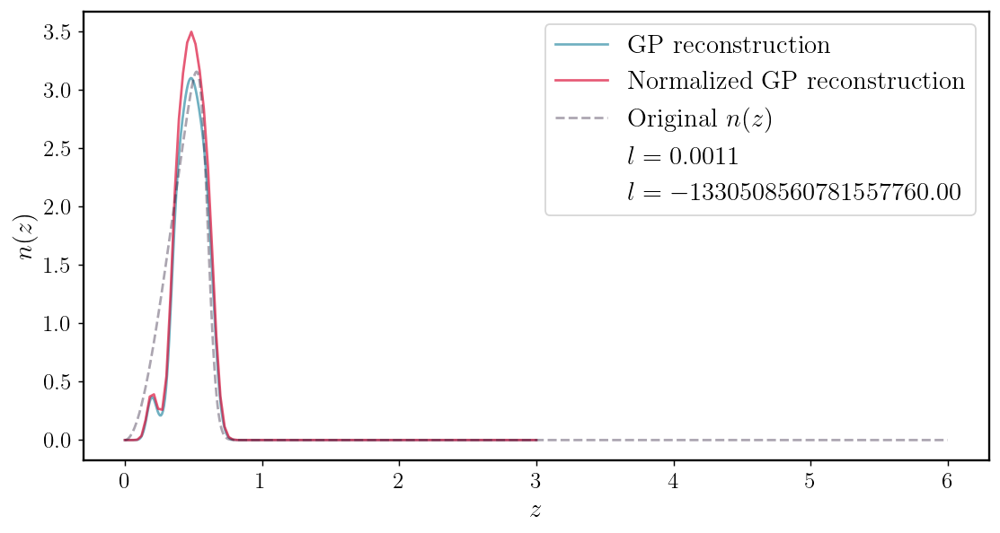

In [22]:
# Plotting the reconstructed n(z) for first step #
import matplotlib as mpl 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))
print(dndz_she_norm.keys())

print(dndzs_gp[0].keys())
ax.plot(z_pred, dndzs_gp[1][1], color=palette[3], alpha=0.7, label=f"GP reconstruction")
ax.plot(zs, dndzs_gp_norm[1][0], color="crimson", alpha=0.7, label="Normalized GP reconstruction")
ax.plot(z_nz, dndz_she_norm[1], '--', color=palette[0], alpha=0.4, label=f"Original $n(z)$")


ax.plot(1,1, alpha=0, label=f"$l = {corr_lens[1]:.4f}$")  # correlation length to 2 decimal places
ax.plot(1,1, alpha=0, label=f"$l = {likelihoods[1]:.2f}$")
ax.set_xlabel(r"$z$", font='Times New Roman', fontsize=16)
ax.set_ylabel(r"$n(z)$", font='Times New Roman', fontsize=16)
ax.legend(loc="upper right", fontsize=16)
#plt.savefig('/home/jipdebuck/plots/GP_reconstruction.png', dpi=600, bbox_inches='tight')

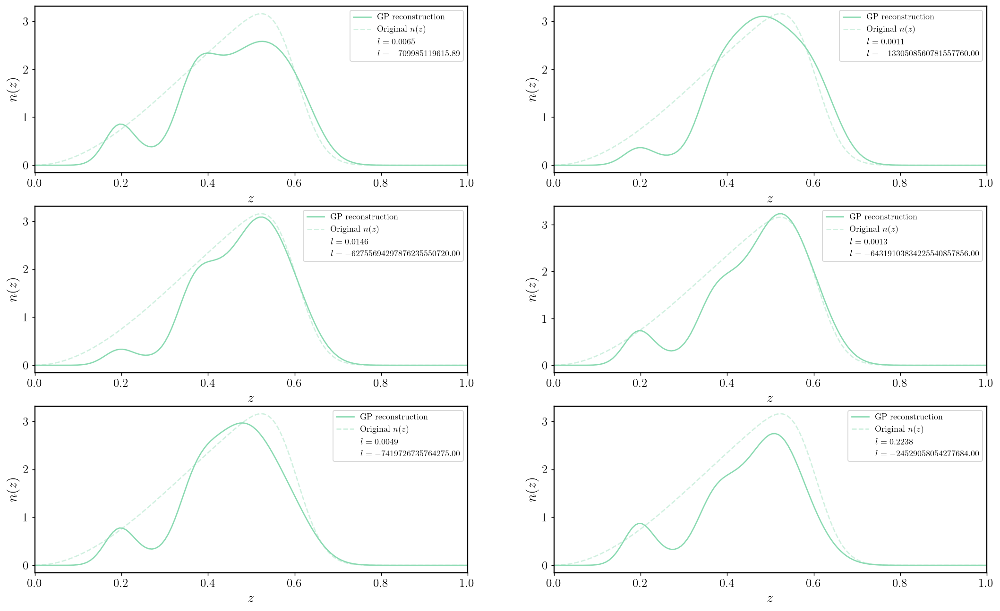

In [23]:
palette = sns.color_palette("mako", 6)
fig, axes = plt.subplots(3,2, figsize=(20, 12))
axes = axes.flatten()
for j in range(6):
    ax = axes[j]
    ax.plot(z_pred, dndzs_gp[j][1], color=palette[i], label=f"GP reconstruction")
    ax.plot(z_nz, dndz_she_norm[1], '--', color=palette[i], alpha=0.4, label=f"Original $n(z)$")
#    ax.plot(myz, dndzs_gp_norm[0][j], color=palette[j], linestyle='--', label=f"{j+1} GP normalized")
#    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

#    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
#    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")
    ax.plot(1,1, alpha=0, label=f"$l = {corr_lens[j]:.4f}$")  # correlation length to 2 decimal places
    ax.plot(1,1, alpha=0, label=f"$l = {likelihoods[j]:.2f}$")
    ax.set_xlabel(r"$z$", font='Times New Roman', fontsize=16)
    ax.set_ylabel(r"$n(z)$", font='Times New Roman', fontsize=16)
    ax.set_xlim(0, 1)
    ax.legend(loc="upper right", fontsize=10)

In [50]:
%matplotlib notebook
import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"



# --- Load your saved arrays ---
# cls_theory[i], dndz_gp[i], corr_lens[i], loglikes[i]

N_frames = len(cells_gp)

fig = plt.figure(figsize=(16, 8))

# Main C_ell panel
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Angular Power Spectrum Evolution")
ax1.set_xlabel(r"$\ell$")
ax1.set_ylabel(r"$C_\ell$")
ax1.set_xscale("log")
ax1.set_yscale("log")

# Plot data + error bars once
#ax1.errorbar(cls_ell, cls_data, yerr=cls_errors, fmt='o', color='black',
#             markersize=4, alpha=0.8, label="Data")

# Theory curve (updated each frame)
line_cl, = ax1.loglog([], [], color="crimson", lw=2, label="Theory")
ax1.legend()
ax1.set_ylim(1e-6, 1)
ax1.set_xlim(10, 2e3)
ells = cells_gp[1]['SHE', 'SHE', 1, 1].ell
# n(z) panel
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("n(z) Evolution")
ax2.set_xlabel(r"$z$")
ax2.set_ylabel(r"$n(z)$")
ax2.set_xlim(0, 1)
ax2.set_ylim(0,3)

line_nz, = ax2.plot([], [], color="steelblue", lw=2)

# Text box for parameters
text_box = ax2.text(
    0.05, 0.95, "", transform=ax2.transAxes,
    fontsize=12, va="top", ha="left"
)

# --- Animation update function ---
def update(i):
    # Update C_ell theory curve
    line_cl.set_data(ells, ells*(2*ells+1)*cells_gp[i]['SHE', 'SHE', 1, 1][0,0])

    # Update n(z)
    line_nz.set_data(z_pred, dndzs_gp[i][1])

    # Update text
    text_box.set_text(
        f"Iteration: {i}\n"
        f"logL = {likelihoods[i]:.2f}\n"
        f"corr_len = {corr_lens[i]:.4f}"
    )

    return line_cl, line_nz, text_box

# --- Create animation ---
anim = FuncAnimation(fig, update, frames=N_frames, interval=50)

plt.tight_layout()
anim

<IPython.core.display.Javascript object>

[1.93403770e-08 1.49896577e-08 1.14704038e-08 8.69006349e-09
 6.54049699e-09 4.90855309e-09 3.68565631e-09 2.77563207e-09
 2.09962088e-09 1.59721424e-09 1.22400261e-09 9.47119403e-10
 7.41206612e-10 5.86507195e-10 4.68547928e-10 3.77442963e-10
 3.06279577e-10 2.50009485e-10 2.05045424e-10 1.68798948e-10
 1.39366832e-10 1.15331046e-10 9.56151120e-11 7.93877755e-11
 6.59969488e-11 5.49241328e-11 4.57525880e-11 3.81446797e-11
 3.18253851e-11 2.65699095e-11 2.21941310e-11 1.85470163e-11]
[-7.09985120e+11 -1.33050856e+18 -6.27556943e+22 -6.43191038e+22
 -7.41972674e+15 -2.45290581e+16]


<IPython.core.display.Javascript object>

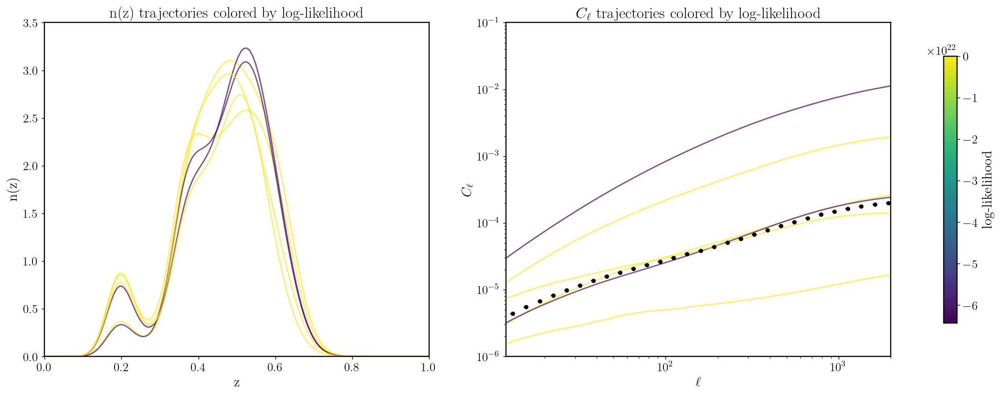

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

logL = np.array([likelihoods[i] for i in sorted(likelihoods.keys())])
cov_she = data_3x2pt["cov"][:32, :32]
err_she = np.sqrt(np.diag(cov_she))
print(err_she)

print(logL)
norm = colors.Normalize(vmin=np.min(logL), vmax=np.max(logL))
cmap = cm.viridis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))

# --- n(z) panel ---
for i in range(N_frames):
    ax1.plot(
        z_pred,
        dndzs_gp[i][1],
        color=cmap(norm(logL[i])),
        alpha=0.7,
        lw=1.5
    )

ax1.set_title("n(z) trajectories colored by log-likelihood")
ax1.set_xlabel("z")
ax1.set_ylabel("n(z)")
ax1.set_xlim(0, 1)
ax1.set_ylim(0,3.5)
# --- C_ell panel ---
for i in range(N_frames):
    ax2.plot(
        ells,
        ells*(2*ells+1)*cells_gp[i]['SHE', 'SHE', 1, 1][0,0],
        color=cmap(norm(logL[i])),
        alpha=0.7,
        lw=1.5
    )
ax2.errorbar(ells, ells*(2*ells+1)*data_3x2pt["cells"]['SHE', 'SHE', 1, 1][0,0], yerr=err_she, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Shear–shear data"
)

ax2.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$C_\ell$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_ylim(1e-6, 0.1)
ax2.set_xlim(12, 2e3)

# --- Colorbar ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8)
cbar.set_label("log-likelihood")
fig


In [28]:
# Loading saved steps #

dndzs_gp = {}
cells_gp = {}
likelihoods = {}
params = {}
dndzs_gp_norm = {}

for i in range(0, 289, 3):
    name = f"/home/jipdebuck/gp_sampling_steps/gp_sampling_step_{i}.0.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp_norm[int(i/3)] = step.item()['dndz_norm']
    cells_gp[int(i/3)] = step.item()['C_ell']
    likelihoods[int(i/3)] = step.item()['loglike']
    params[int(i/3)] = step.item()['params']


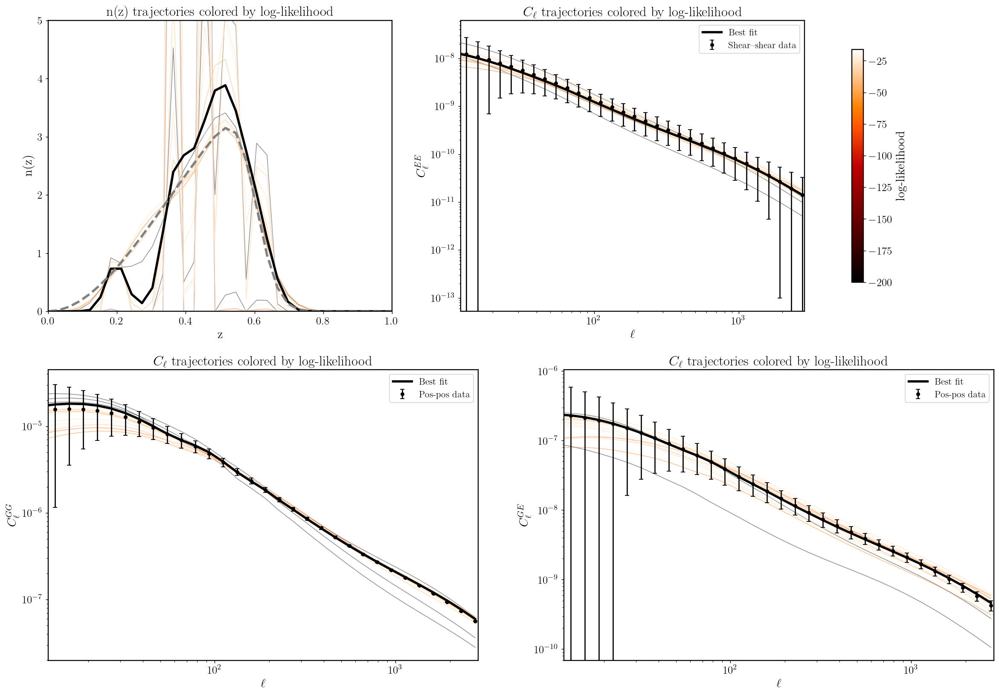

In [51]:
from matplotlib import colors
import matplotlib.cm as cm

logL = np.array([likelihoods[i] for i in sorted(likelihoods.keys())])


vmin = np.percentile(logL, 10)
vmax = np.percentile(logL, 90)
norm = colors.Normalize(vmin=-200, vmax=vmax)
cmap = cm.gist_heat
cov_she = data_3x2pt["cov"][:32, :32]
err_she = np.sqrt(np.diag(cov_she))
cov_GGL= cov_bin1[32:64, 32:64]
err_GGL = np.sqrt(np.diag(cov_GGL))
cov_GC = cov_bin1[64:96, 64:96]
err_GC = np.sqrt(np.diag(cov_GC))

fig, axes = plt.subplots(2, 2, figsize=(22, 15))
ax1, ax2, ax3, ax4 = axes.flatten()
best_idx = np.argmax(logL)
best_step = best_idx


for i in range(0, 97, 5):   # plot fewer curves
    ax1.plot(
        zs,
        dndzs_gp_norm[i][0],
        color=cmap(norm(logL[i])),
        alpha=0.4,
        lw=1.0
    )

ax1.plot(zs, dndzs_gp_norm[best_step][0], color='black', lw=3, label='Best fit')
ax1.plot(zs, my_dndz_she_norm[0], color='gray', lw=3, linestyle='--', label='Original')
for i in range(0, 97, 5):
    ells_WL = cells_gp[i]['SHE','SHE',1,1].ell
    ells_GC = cells_gp[i]['POS','POS',1,1].ell
    ells_GGL = cells_gp[i]['POS','SHE',1,1].ell
    ax2.plot(
        ells_WL,
        cells_gp[i]['SHE','SHE',1,1][0,0],
        color=cmap(norm(logL[i])),
        alpha=0.4,
        lw=1.0
    )
    ax3.plot(
        ells_GC,
        cells_gp[i]['POS','POS',1,1],
        color=cmap(norm(logL[i])),
        alpha=0.4,
        lw=1.0
    )
    ax4.plot(
        ells,
        cells_gp[i]['POS','SHE',1,1][0],
        color=cmap(norm(logL[i])),
        alpha=0.4,
        lw=1.0
    )
ax1.set_title("n(z) trajectories colored by log-likelihood")
ax1.set_xlabel("z")
ax1.set_ylabel("n(z)")
ax1.set_xlim(0, 1)
ax1.set_ylim(0,5)
ells = cells_gp[best_step]['SHE','SHE',1,1].ell
ax2.plot(ells, cells_gp[best_step]['SHE','SHE',1,1][0,0],
         color='black', label='Best fit', lw=3)
ax2.errorbar(ells, data_3x2pt["cells"]['SHE', 'SHE', 1, 1][0,0], yerr=err_she, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Shear–shear data"
)

ax2.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax2.legend()
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$C_\ell^{EE}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(12, max(ells)+100)

ells = cells_gp[best_step]['POS','POS',1,1].ell
ax3.plot(ells, cells_gp[best_step]['POS','POS',1,1],
         color='black', label='Best fit', lw=3)
ax3.errorbar(ells, data_3x2pt["cells"]['POS', 'POS', 1, 1], yerr=err_GC, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Pos-pos data"
)

ax3.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax3.legend()
ax3.set_xlabel(r"$\ell$")
ax3.set_ylabel(r"$C_\ell^{GG}$")
ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlim(12, max(ells)+100)

ells = cells_gp[best_step]['POS','SHE',1,1].ell
ax4.plot(ells, cells_gp[best_step]['POS','SHE',1,1][0],
         color='black', label='Best fit', lw=3)
ax4.errorbar(ells, data_3x2pt["cells"]['POS', 'SHE', 1, 1][0], yerr=err_GGL, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Pos-pos data"
)

ax4.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax4.legend()
ax4.set_xlabel(r"$\ell$")
ax4.set_ylabel(r"$C_\ell^{GE}$")
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlim(12, max(ells)+100)

# --- Colorbar ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8)
cbar.set_label("log-likelihood")

In [49]:
# Saving 6 recent steps

dndzs_gp_last_6 = {}
cells_gp_last_6 = {}
likelihoods_last_6 = {}
params_last_6 = {}
dndzs_gp_norm_last_6 = {}

counter = 0
for i in range(309, 325, 3):
    name_last_6 = f"/home/jipdebuck/gp_sampling_steps/gp_sampling_step_{i}.0.npy"
    step_last_6 = np.load(name_last_6, allow_pickle=True)
    dndzs_gp_norm_last_6[counter] = step_last_6.item()['dndz_norm']
    cells_gp_last_6[counter] = step_last_6.item()['C_ell']
    likelihoods_last_6[counter] = step_last_6.item()['loglike']
    params_last_6[counter] = step_last_6.item()['params']
    counter += 1
print(likelihoods_last_6)

{0: np.float64(-16.500558873947842), 1: np.float64(-25.25011108553767), 2: np.float64(-11.320242548125343), 3: np.float64(-21.059953261989694), 4: np.float64(-41.69002567872896), 5: np.float64(-20.850856062977023)}


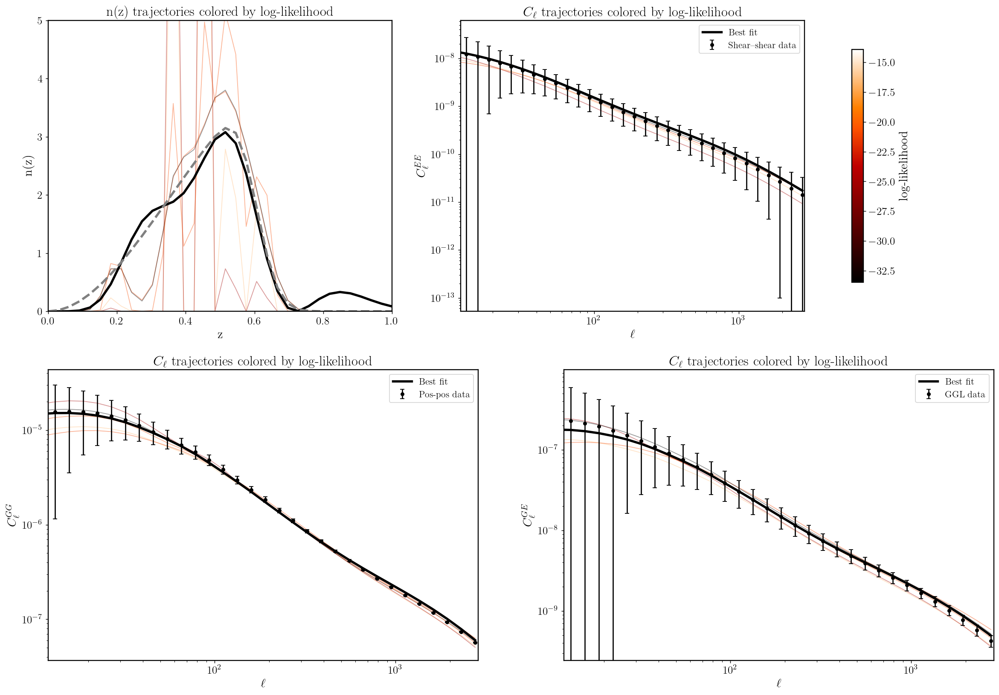

In [52]:
logL_last_6 = np.array([likelihoods_last_6[i] for i in sorted(likelihoods_last_6.keys())])

vmin_last_6 = np.percentile(logL_last_6, 10)
vmax_last_6 = np.percentile(logL_last_6, 90)
norm_last_6 = colors.Normalize(vmin=vmin_last_6, vmax=vmax_last_6)
cmap_last_6 = cm.gist_heat

cov_she_last_6 = data_3x2pt["cov"][:32, :32]
err_she_last_6 = np.sqrt(np.diag(cov_she_last_6))
cov_GGL_last_6 = cov_bin1[32:64, 32:64]
err_GGL_last_6 = np.sqrt(np.diag(cov_GGL_last_6))
cov_GC_last_6 = cov_bin1[64:96, 64:96]
err_GC_last_6 = np.sqrt(np.diag(cov_GC_last_6))

fig, axes = plt.subplots(2, 2, figsize=(22, 15))
ax1, ax2, ax3, ax4 = axes.flatten()
best_idx_last_6 = np.argmax(logL_last_6)
best_step_last_6 = best_idx_last_6

for i in sorted(dndzs_gp_norm_last_6.keys()):
    ax1.plot(
        zs,
        dndzs_gp_norm_last_6[i][0],
        color=cmap_last_6(norm_last_6(logL_last_6[i])),
        alpha=0.4,
        lw=1.0
    )

ax1.plot(zs, dndzs_gp_norm_last_6[best_step_last_6][0], color='black', lw=3, label='Best fit')
ax1.plot(zs, my_dndz_she_norm[0], color='gray', lw=3, linestyle='--', label='Original')

for i in sorted(cells_gp_last_6.keys()):
    ells_WL_last_6 = cells_gp_last_6[i]['SHE','SHE',1,1].ell
    ells_GC_last_6 = cells_gp_last_6[i]['POS','POS',1,1].ell
    ells_GGL_last_6 = cells_gp_last_6[i]['POS','SHE',1,1].ell

    ax2.plot(
        ells_WL_last_6,
        cells_gp_last_6[i]['SHE','SHE',1,1][0,0],
        color=cmap_last_6(norm_last_6(logL_last_6[i])),
        alpha=0.4,
        lw=1.0
    )
    ax3.plot(
        ells_GC_last_6,
        cells_gp_last_6[i]['POS','POS',1,1],
        color=cmap_last_6(norm_last_6(logL_last_6[i])),
        alpha=0.4,
        lw=1.0
    )
    ax4.plot(
        ells_GGL_last_6,
        cells_gp_last_6[i]['POS','SHE',1,1][0],
        color=cmap_last_6(norm_last_6(logL_last_6[i])),
        alpha=0.4,
        lw=1.0
    )

ax1.set_title("n(z) trajectories colored by log-likelihood")
ax1.set_xlabel("z")
ax1.set_ylabel("n(z)")
ax1.set_xlim(0, 1)
ax1.set_ylim(0,5)

ells_last_6 = cells_gp_last_6[best_step_last_6]['SHE','SHE',1,1].ell
ax2.plot(ells_last_6, cells_gp_last_6[best_step_last_6]['SHE','SHE',1,1][0,0],
         color='black', label='Best fit', lw=3)
ax2.errorbar(ells_last_6, data_3x2pt["cells"]['SHE', 'SHE', 1, 1][0,0], yerr=err_she_last_6, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Shear–shear data"
)

ax2.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax2.legend()
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$C_\ell^{EE}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(12, max(ells_last_6)+100)

ells_last_6 = cells_gp_last_6[best_step_last_6]['POS','POS',1,1].ell
ax3.plot(ells_last_6, cells_gp_last_6[best_step_last_6]['POS','POS',1,1],
         color='black', label='Best fit', lw=3)
ax3.errorbar(ells_last_6, data_3x2pt["cells"]['POS', 'POS', 1, 1], yerr=err_GC_last_6, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Pos-pos data"
)

ax3.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax3.legend()
ax3.set_xlabel(r"$\ell$")
ax3.set_ylabel(r"$C_\ell^{GG}$")
ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlim(12, max(ells_last_6)+100)

ells_last_6 = cells_gp_last_6[best_step_last_6]['POS','SHE',1,1].ell
ax4.plot(ells_last_6, cells_gp_last_6[best_step_last_6]['POS','SHE',1,1][0],
         color='black', label='Best fit', lw=3)
ax4.errorbar(ells_last_6, data_3x2pt["cells"]['POS', 'SHE', 1, 1][0], yerr=err_GGL_last_6, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="GGL data"
)

ax4.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax4.legend()
ax4.set_xlabel(r"$\ell$")
ax4.set_ylabel(r"$C_\ell^{GE}$")
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlim(12, max(ells_last_6)+100)

sm_last_6 = cm.ScalarMappable(norm=norm_last_6, cmap=cmap_last_6)
sm_last_6.set_array([])
cbar_last_6 = fig.colorbar(sm_last_6, ax=[ax1, ax2], shrink=0.8)
cbar_last_6.set_label("log-likelihood")

### 10. Normalizing flow with tight correlation length prior

In [25]:
# Loading saved steps #

dndzs_gp = {}
cells_gp = {}
likelihoods = {}
params = {}
dndzs_gp_norm = {}

for i in range(216, 231):
    name = f"/home/jipdebuck/gp_sampling_steps_2/gp_sampling_step_{i}.0.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp_norm[i-216] = step.item()['dndz_norm']
    cells_gp[i-216] = step.item()['C_ell']
    likelihoods[i-216] = step.item()['loglike']
    params[i-216] = step.item()['params']
print(params.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])


dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
0
[  -7.41304297   -9.10983111  -38.06547787  -43.49241392  -59.85367252
  -43.91790977  -63.68552593  -22.36576069 -125.51791546  -64.49897112
  -53.6250345   -60.6981776   -70.60346882  -87.0492137   -30.52432227]


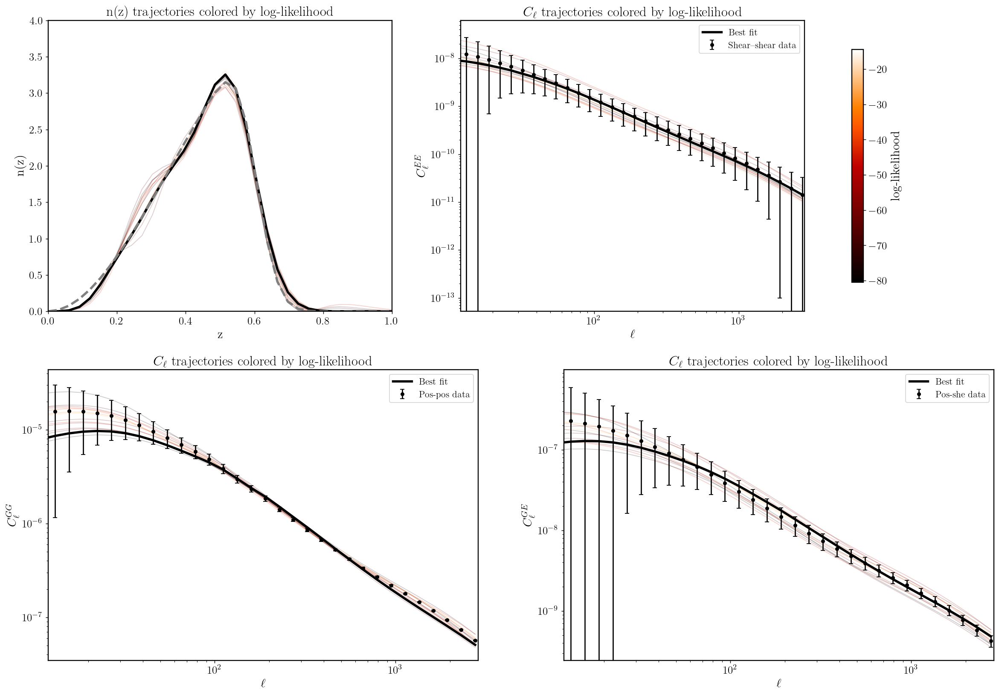

In [26]:
from matplotlib import colors
import matplotlib.cm as cm

logL = np.array([likelihoods[i] for i in range(0, 15)])

print(dndzs_gp_norm.keys())
print(cells_gp.keys())
vmin = np.percentile(logL, 10)
vmax = np.percentile(logL, 90)
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.gist_heat
cov_she = data_3x2pt["cov"][:32, :32]
err_she = np.sqrt(np.diag(cov_she))
cov_GGL= cov_bin1[32:64, 32:64]
err_GGL = np.sqrt(np.diag(cov_GGL))
cov_GC = cov_bin1[64:96, 64:96]
err_GC = np.sqrt(np.diag(cov_GC))

fig, axes = plt.subplots(2, 2, figsize=(22, 15))
ax1, ax2, ax3, ax4 = axes.flatten()
best_idx = np.argmax(logL)
print(best_idx)
print(logL)
best_step = best_idx


for i in range(0, 15):   # plot fewer curves
    ax1.plot(
        zs,
        dndzs_gp_norm[i][0],
        color=cmap(norm(logL[i])),
        alpha=0.2,
        lw=1.0
    )

ax1.plot(zs, dndzs_gp_norm[best_step][0], color='black', lw=3, label='Best fit')
ax1.plot(zs, my_dndz_she_norm[0], color='gray', lw=3, linestyle='--', label='Original')
for i in range(0, 15):
    ells_WL = cells_gp[i]['SHE','SHE',1,1].ell
    ells_GC = cells_gp[i]['POS','POS',1,1].ell
    ells_GGL = cells_gp[i]['POS','SHE',1,1].ell
    ax2.plot(
        ells_WL,
        cells_gp[i]['SHE','SHE',1,1][0,0],
        color=cmap(norm(logL[i])),
        alpha=0.2,
        lw=1.0
    )
    ax3.plot(
        ells_GC,
        cells_gp[i]['POS','POS',1,1],
        color=cmap(norm(logL[i])),
        alpha=0.2,
        lw=1.0
    )
    ax4.plot(
        ells_GGL,
        cells_gp[i]['POS','SHE',1,1][0],
        color=cmap(norm(logL[i])),
        alpha=0.2,
        lw=1.0
    )
ax1.set_title("n(z) trajectories colored by log-likelihood")
ax1.set_xlabel("z")
ax1.set_ylabel("n(z)")
ax1.set_xlim(0, 1)
ax1.set_ylim(0,4)
ells = cells_gp[best_step]['SHE','SHE',1,1].ell
ax2.plot(ells, cells_gp[best_step]['SHE','SHE',1,1][0,0],
         color='black', label='Best fit', lw=3)
ax2.errorbar(ells, data_3x2pt["cells"]['SHE', 'SHE', 1, 1][0,0], yerr=err_she, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Shear–shear data"
)

ax2.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax2.legend()
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$C_\ell^{EE}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(12, max(ells)+100)

ells = cells_gp[best_step]['POS','POS',1,1].ell
ax3.plot(ells, cells_gp[best_step]['POS','POS',1,1],
         color='black', label='Best fit', lw=3)
ax3.errorbar(ells, data_3x2pt["cells"]['POS', 'POS', 1, 1], yerr=err_GC, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Pos-pos data"
)

ax3.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax3.legend()
ax3.set_xlabel(r"$\ell$")
ax3.set_ylabel(r"$C_\ell^{GG}$")
ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlim(12, max(ells)+100)

ells = cells_gp[best_step]['POS','SHE',1,1].ell
ax4.plot(ells, cells_gp[best_step]['POS','SHE',1,1][0],
         color='black', label='Best fit', lw=3)
ax4.errorbar(ells, data_3x2pt["cells"]['POS', 'SHE', 1, 1][0], yerr=err_GGL, fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label="Pos-she data"
)

ax4.set_title(r"$C_\ell$ trajectories colored by log-likelihood")
ax4.legend()
ax4.set_xlabel(r"$\ell$")
ax4.set_ylabel(r"$C_\ell^{GE}$")
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlim(12, max(ells)+100)

# --- Colorbar ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8)
cbar.set_label("log-likelihood")

In [27]:
print("Best dictionary key:", best_step)
print("Best logL:", likelihoods[best_step])
print("Check:", logL[best_idx])

Best dictionary key: 0
Best logL: -7.413042970814409
Check: -7.413042970814409


### Likelihood scatter plot

In [30]:
logL_prior_old = []
logL_total_old = []
logL_data_old = []
logL_prior_new = []
logL_total_new = []
logL_data_new = []

for i in range(1242):
    name = f"/home/jipdebuck/gp_sampling_steps_new/gp_sampling_step_{i}.0.npy"
    step = np.load(name, allow_pickle=True)
    logL_prior_new.append(step.item()['logprior'])
    logL_total_new.append(step.item()['loglike'])
    logL_data_new.append(step.item()['loglike']-step.item()['logprior'])

for i in range(1364):
    name = f"/home/jipdebuck/gp_sampling_steps_old/gp_sampling_step_prior{i}.0.npy"
    step = np.load(name, allow_pickle=True)
    logL_prior_old.append(step.item()['logprior_flow'])
    logL_total_old.append(step.item()['loglike_total'])
    logL_data_old.append(step.item()['loglike_data'])

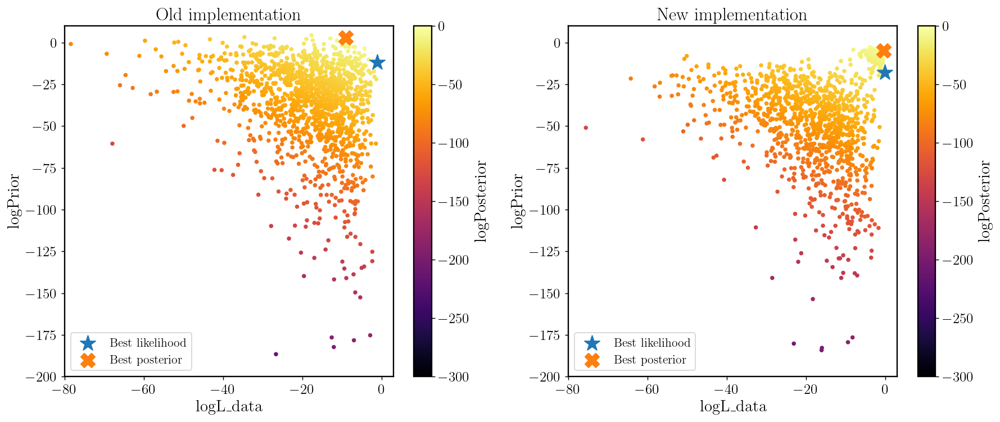

In [36]:
from matplotlib import colors

logL_prior_old = np.array(logL_prior_old)
logL_total_old = np.array(logL_total_old)
logL_data_old = np.array(logL_data_old)

logL_prior_new = np.array(logL_prior_new)
logL_total_new = np.array(logL_total_new)
logL_data_new = np.array(logL_data_new)

norm = colors.Normalize(vmin=-300, vmax=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
sc1 = axes[0].scatter(
    logL_data_old,
    logL_prior_old,
    c=logL_total_old,
    s=10,
    cmap='inferno',
    norm=norm
)

best_like_old = np.argmax(logL_data_old)
best_post_old = np.argmax(logL_total_old)

axes[0].scatter(
    logL_data_old[best_like_old],
    logL_prior_old[best_like_old],
    marker='*',
    s=250,
    label='Best likelihood'
)

axes[0].scatter(
    logL_data_old[best_post_old],
    logL_prior_old[best_post_old],
    marker='X',
    s=200,
    label='Best posterior'
)

axes[0].set_title("Old implementation")
axes[0].set_ylim(-200, 10)
axes[0].set_xlim(-80, 3)
axes[0].set_xlabel("logL_data")
axes[0].set_ylabel("logPrior")
axes[0].legend()

cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label("logPosterior")
sc2 = axes[1].scatter(
    logL_data_new,
    logL_prior_new,
    c=logL_total_new,
    s=10,
    cmap='inferno',
    norm=norm
)

best_like_new = np.argmax(logL_data_new)
best_post_new = np.argmax(logL_total_new)

axes[1].scatter(
    logL_data_new[best_like_new],
    logL_prior_new[best_like_new],
    marker='*',
    s=250,
    label='Best likelihood'
)

axes[1].scatter(
    logL_data_new[best_post_new],
    logL_prior_new[best_post_new],
    marker='X',
    s=200,
    label='Best posterior'
)

axes[1].set_title("New implementation")
axes[1].set_xlabel("logL_data")
axes[1].set_ylim(-200, 10)
axes[1].set_xlim(-80, 3)
axes[1].set_ylabel("logPrior")
axes[1].legend()

cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label("logPosterior")

plt.tight_layout()

In [ ]:
dndzs_gp = {}
cells_gp = {}
likelihoods = {}
params = {}
dndzs_gp_norm = {}

for i in range(216, 231):
    name = f"/home/jipdebuck/gp_sampling_steps_2/gp_sampling_step_{i}.0.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp_norm[i-216] = step.item()['dndz_norm']
    cells_gp[i-216] = step.item()['C_ell']
    likelihoods[i-216] = step.item()['loglike']
    params[i-216] = step.item()['params']
print(params.keys())

### Creating ensemble from the realistic $n(z)$

In [26]:
from astropy.io import fits
from astropy.table import Table

ops_pos = fits.open("/home/jipdebuck/EUC_PHZ_TOMBINZ__20260523T193234.821098Z_00.00.fits")
ops_she = fits.open("/home/jipdebuck/EUC_PHZ_TOMBINZ__20260523T193234.818764Z_00.00.fits")

ops_pos_N = fits.open("/home/jipdebuck/EUC_PHZ_TOMBINZ__20260524T070535.828556Z_00.00_North.fits")
ops_she_N = fits.open("/home/jipdebuck/EUC_PHZ_TOMBINZ__20260524T070535.822774Z_00.00_North.fits")

In [31]:
def normalize_dndz_original(nz_example, z_nz):
    normalized = {}
    for bin, nz in enumerate(nz_example):
        normalized[bin+1] = nz / integrate.trapezoid(nz, z_nz)
    return normalized

In [27]:
z_ops = np.arange(ops_pos[1].header['Z_STEP_NUMBER']+1)*ops_pos[1].header['Z_Step']

In [30]:
print(ops_she[1].data['N_Z'][:,:601])

[[ 2.37573467e-02  3.57316954e-02  3.99780737e-02 ...  2.28965429e-06
   5.86550437e-06  0.00000000e+00]
 [ 2.41962176e-02  3.86036867e-02  4.99176135e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.11330465e-02  1.78528814e-02  2.17740323e-02 ...  1.52633980e-06
   3.91008930e-06  0.00000000e+00]
 [ 0.00000000e+00  2.32309008e-06  1.85701090e-04 ... -3.05250889e-06
  -7.81974132e-06  0.00000000e+00]
 [ 1.45315065e-03  2.58128999e-03  3.10407059e-03 ... -4.57879620e-06
  -1.17296962e-05  0.00000000e+00]
 [ 1.33247370e-03  4.13025445e-03  8.43593724e-03 ... -3.05252923e-06
  -7.81979342e-06  0.00000000e+00]]


In [34]:
# Normalize both dndz_pos and dndz_she

nz_pos_norm_S = normalize_dndz_original(ops_pos[1].data['N_Z'][:,:601], z_ops)
nz_she_norm_S = normalize_dndz_original(ops_she[1].data['N_Z'][:,:601], z_ops)
nz_pos_norm_N = normalize_dndz_original(ops_pos_N[1].data['N_Z'][:,:601], z_ops)
nz_she_norm_N = normalize_dndz_original(ops_she_N[1].data['N_Z'][:,:601], z_ops)

# Resampling the normalized dndz with 100 values
#my_dndz_pos_norm_S = resample_dndz(nz_pos_norm_S, z_pos_S, zs)
#my_dndz_she_norm_S = resample_dndz(nz_she_norm_S, z_she_S, zs)
#my_dndz_pos_norm_N = resample_dndz(nz_pos_norm_N, z_pos_N, zs)
#my_dndz_she_norm_N = resample_dndz(nz_she_norm_N, z_she_N, zs)

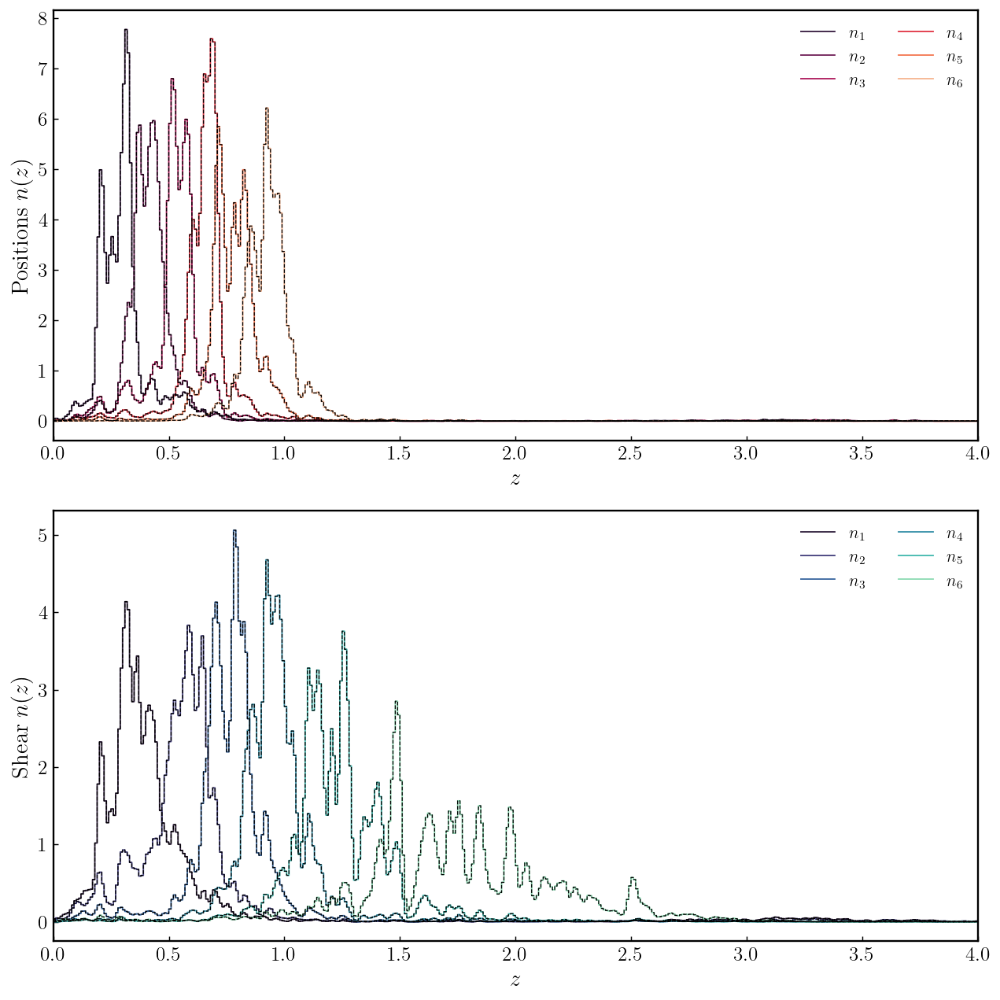

In [36]:
# Plotting of original n(z) distributions #

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(nz_pos_norm_S.keys(), sns.color_palette("rocket", len(nz_pos_norm_S)))):
    axs[0].step(z_ops, nz_pos_norm_S[key], label=f'$n_{{{i+1}}}$', linewidth=1, color=color)
#    axs[0].step(z_ops, nz_pos_S[key][:601], color=color, linewidth=2, linestyle='--', label='Unnormalized')

# Plot shear n(z)
for j, (key, color) in enumerate(zip(nz_she_norm_S.keys(), sns.color_palette("mako", len(nz_she_norm_S)))):
    axs[1].step(z_ops, nz_she_norm_S[key], label=f'$n_{{{j+1}}}$', linewidth=1, color=color)
#    axs[1].step(z_ops, nz_she_S[key][:601], color=color, linewidth=2, linestyle='--', label='Unnormalized')

axs[1].step(z_ops, ops_she[1].data['N_Z'][:,:601].T, linestyle='--', color='black', linewidth=0.7, alpha=1)
axs[0].step(z_ops, ops_pos[1].data['N_Z'][:,:601].T, linestyle='--', color='black', linewidth=0.7, alpha=1)
#plt.step(z_ops, ops_pos[1].data['N_Z'][:,:601].T, lw=2)
plt.xlim([0,3.])
plt.xlabel('z')
plt.tight_layout()

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [45]:
z_ens_list_pos_S, nz_ensemble_list_pos_S = zip(*[
    generate_bin1_ensemble_unnorm(
        N_ens=50, 
        nz=nz_pos_norm_S[i], 
        N_z=601,
        mean_shift_sigma=0.03,
        width_shift_sigma=0.05,
        shape_noise_sigma=0.1
    )
    for i in range(1, 7)
])

In [46]:
x_nodes_list_pos_S = []
Y_nodes_list_pos_S = []

for b in range(len(nz_ensemble_list_pos_S)):
    nz_ens = nz_ensemble_list_pos_S[b]     
    z_grid = z_ens_list_pos_S[b]           

    x_nodes, Y_nodes = compute_cdf_nodes_per_bin(z_grid, nz_ens, M=5)

    x_nodes_list_pos_S.append(x_nodes)
    Y_nodes_list_pos_S.append(Y_nodes)

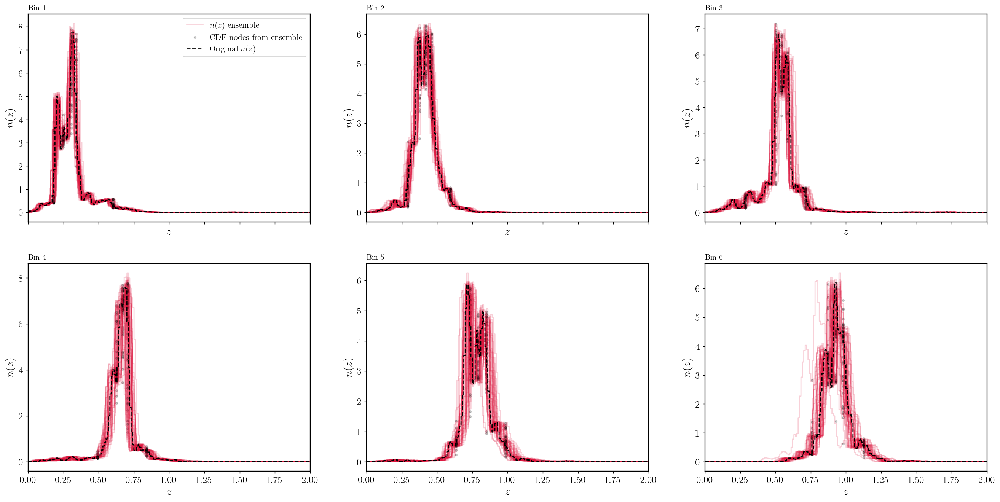

In [56]:
z_grid = z_ens_list_pos_S[0]

fig, axes = plt.subplots(2, 3, figsize=(25,12), sharex=True)
axes = axes.flatten()
for i in range(len(nz_ensemble_list_pos_S)):
    nz_ens = nz_ensemble_list_pos_S[i]
    for j, nz in enumerate(nz_ens):
        if i == 0 and j == 0:
            axes[i].step(z_grid, nz, color='crimson', alpha=0.2, label='$n(z)$ ensemble')
            axes[i].scatter(x_nodes_list_pos_S[i], Y_nodes_list_pos_S[i][j], marker='.', color='black', alpha=0.2, zorder=2, label='CDF nodes from ensemble')
        else:
            axes[i].step(z_grid, nz, color='crimson', alpha=0.2)
            axes[i].scatter(x_nodes_list_pos_S[i], Y_nodes_list_pos_S[i][j], marker='.', color='black', alpha=0.2, zorder=2)
        
    axes[i].set_xlim(0, 2)
    axes[i].set_title(f"Bin {i+1}", loc="left", fontsize=11)
    axes[i].set_xlabel("$z$")
    axes[i].set_ylabel("$n(z)$")
    axes[i].step(z_ops, nz_pos_norm_S[i+1], linestyle='--', lw=1.5, c='black', label='Original $n(z)$')
axes[0].legend()

In [58]:
flows_pos_S = []
means_pos_S = []
stds_pos_S = []

for b in range(len(Y_nodes_list_pos_S)):
    print(f"Training flow for bin {b+1}")
    flow_b, mean_b, std_b = normalizing_flow_per_bin(Y_nodes_list_pos_S[b])
    flows_pos_S.append(flow_b)
    means_pos_S.append(mean_b)
    stds_pos_S.append(std_b)

Training flow for bin 1


Training flow:   0%|                                   | 0/3000 [00:00<?, ?it/s]/home/jipdebuck/miniconda3/envs/cloe_env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Training flow: 100%|███████████████████████| 3000/3000 [00:14<00:00, 204.54it/s]


Training flow for bin 2


Training flow: 100%|███████████████████████| 3000/3000 [00:17<00:00, 170.40it/s]


Training flow for bin 3


...

Training flow: 100%|███████████████████████| 3000/3000 [00:17<00:00, 169.10it/s]


Training flow for bin 5


Training flow: 100%|███████████████████████| 3000/3000 [00:15<00:00, 191.39it/s]


Training flow for bin 6


Training flow: 100%|███████████████████████| 3000/3000 [00:17<00:00, 173.79it/s]


In [77]:
def plot_all_bins(flows, means, stds, x_nodes_list, Y_nodes_list,
                  nz_ensemble_list, z_ens_list,
                  z_pred, reconstruct_nz_from_nodes_gp_square, nz_pos_norm, z_ops):
    fig, axes = plt.subplots(len(flows), 2, figsize=(22, 4*len(flows)))
    for b in range(len(flows)):
        flow = flows[b]
        mean = means[b]
        std = stds[b]
        x_nodes = x_nodes_list[b]
        Y_nodes = Y_nodes_list[b]
        nz_ens = nz_ensemble_list[b]
        z_grid = z_ens_list[b]

        ax_left = axes[b, 0]
        ax_right = axes[b, 1]
        U_flow_norm = flow.sample(50).detach().numpy()
        U_flow = U_flow_norm * std + mean
        U_flow = np.clip(U_flow, -20, 20)
        Y_flow = np.exp(U_flow)

        for i, y in enumerate(Y_flow):
            y_pred = reconstruct_nz_from_nodes_gp_square(
                z_pred,
                x_nodes,
                y,
                z_bounds=(0.0, 3.0),
                corr_len=0.02,
                amp=0.04,
                alpha=0.0,  # <-- set 0 for interpolation
                kernel_class=RBF,
                nu=1.5,
                return_std=False,
            )
            ax_left.step(z_pred, y_pred, color="crimson", alpha=0.2)
            z_pred_res = z_pred.reshape(-1, 1)
            y_norm = resample_dndz_gp({"1": y_pred}, z_pred_res, zs)
            if i == 0:
                ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2, label='Nodes sampled from flow')
            else:
                ax_left.scatter(x_nodes, y, color='gray', marker='.', alpha=0.2)
        if min(x_nodes)-0.5 < 0:
            ax_left.set_xlim(0, max(x_nodes)+0.5)
        else:
            ax_left.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
        ax_left.set_title(f"Bin {b+1}: Normalizing Flow Prior Samples")
        ax_left.set_xlabel("$z$")
        ax_left.set_ylabel("$n(z)$")
        ax_left.set_ylim(0, Y_nodes.max()+1)
        ax_left.legend()
        for i in range(nz_ens.shape[0]):
            ax_right.step(
                z_grid,
                nz_ens[i],
                color="crimson", alpha=0.2, lw=0.8
            )
        for i, nodes in enumerate(Y_nodes):
            if i == 0:
                ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2, label='Nodes from ensemble')
            else:
                ax_right.scatter(x_nodes, nodes, color='gray', marker='.', alpha=0.2)
        if min(x_nodes)-0.5 < 0:
            ax_right.set_xlim(0, max(x_nodes)+0.5)
        else:
            ax_right.set_xlim(min(x_nodes)-0.5, max(x_nodes)+0.5)
        ax_right.step(z_ops, nz_pos_norm[b+1], linestyle='--', lw=1.5, c='black', label='Original $n(z)$')
        ax_right.set_title(f"Bin {b+1}: Ensemble Curves")
        ax_right.set_xlabel("$z$")
        ax_right.set_ylabel("$n(z)$")
        ax_right.set_ylim(0, Y_nodes.max()+1)

    plt.tight_layout()
    return fig

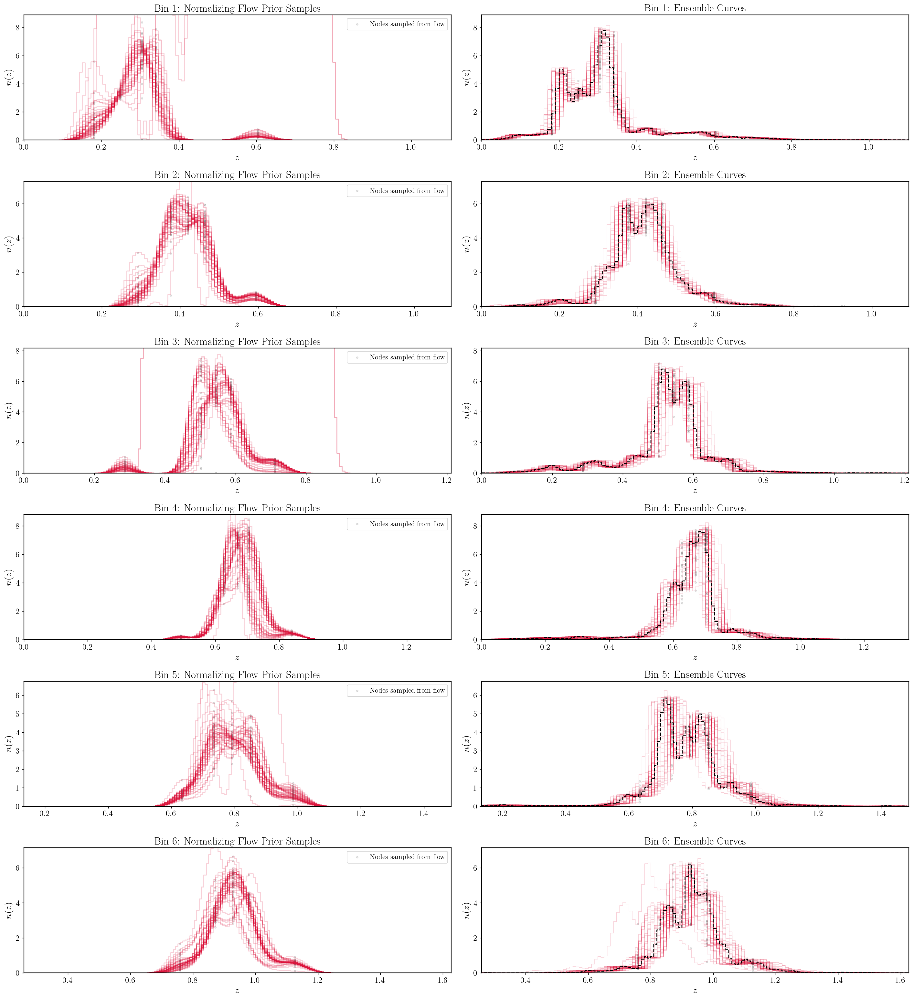

In [78]:
fig = plot_all_bins(
    flows_pos_S, means_pos_S, stds_pos_S,
    x_nodes_list_pos_S, Y_nodes_list_pos_S,
    nz_ensemble_list_pos_S, z_ens_list_pos_S,
    z_pred, reconstruct_nz_from_nodes_gp_square, nz_pos_norm_S, z_ops
)

In [16]:
import numpy as np
from scipy import integrate
import time
from scipy.stats import norm
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)

name_to_chain_gp = '3x2pt_LCDM_DR1_GP_ELR_square'

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')


# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)


def x_log1p(z, zmax):
    """Map z to x in [0,1] using log(1+z)."""
    return np.log1p(z) / np.log1p(zmax)

def kernel_fixed(kernel_class, amp, ell, nu=1.5, amp_bounds=(1e-6, 10.0)):
    """
    Kernel with fixed length-scale ell, fixed (or bounded) amplitude amp.
    We keep optimizer=None, so amp and ell are not learned during GP fitting.
    """
    if kernel_class is Matern:
        return C(amp, amp_bounds) * Matern(length_scale=ell, nu=nu, length_scale_bounds="fixed")
    else:
        return C(amp, amp_bounds) * RBF(length_scale=ell, length_scale_bounds="fixed")
    
def reconstruct_nz_from_nodes_gp_square(
    z_pred,
    z_nodes,
    theta_nodes,
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0,                 # <-- set 0 for interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False

):
    """
    This is the "inferred by the nodes" GP:
      Train on (zmin,0), (z_nodes, theta_nodes), (zmax,0).
      Predict on z_pred.

    IMPORTANT:
    - Do NOT clip/renormalize here if you want the GP mean to pass through nodes.
    - If you need positivity/normalization, do it in the node parameterization
      (e.g., sample log-theta) or use a log-GP model.
    """
    zmin, zmax = z_bounds
    z_pred = np.asarray(z_pred, float)
    z_train = np.concatenate([[zmin], np.asarray([z_nodes], float), [zmax]])
    y_train_squareroot = np.concatenate([[0], np.asarray(np.sqrt([theta_nodes]), float), [0]])

    X_train = x_log1p(z_train, zmax).reshape(-1, 1)
    X_pred  = x_log1p(z_pred, zmax).reshape(-1, 1)

    kernel = kernel_fixed(kernel_class, amp=amp, ell=corr_len, nu=nu, amp_bounds=(1e-6, 10.0))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=False,
        alpha=float(alpha),
        copy_X_train=False,
        random_state=0,
    )
    gp.fit(X_train, y_train_squareroot)

    if return_std:
        y_pred_squareroot, y_std = gp.predict(X_pred, return_std=True)
        y_pred = y_pred_squareroot**2
        return y_pred, y_std, gp
    else:
        y_pred_squareroot = gp.predict(X_pred, return_std=False)
        y_pred = y_pred_squareroot**2
        return y_pred

def reconstruct_all_bins_square(
    z_pred,
    z_nodes_all_bins,
    n_nodes_all_bins,            # list of arrays, each shape (M,)
    z_bounds=(0.0, 3.0),
    corr_len=0.03,
    amp=0.04,
    alpha=0.0,                 # <-- use 0.0 if you want interpolation
    kernel_class=RBF,
    nu=1.5,
    return_std=False
):
    """
    Decode all bins at once: returns list of n_b(z_pred).
    If return_std=True, returns list of (mean,std) per bin.
    """
    out = {}
    for b, z_node in enumerate(z_nodes_all_bins):
        print(z_node)
        if return_std:
            mean, std, _ = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=z_node,
                theta_nodes=n_nodes_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=True
            )
            out[b+1] = (mean, std)
        else:
            nz = reconstruct_nz_from_nodes_gp_square(
                z_pred=z_pred,
                z_nodes=z_node,
                theta_nodes=n_nodes_all_bins[b],
                z_bounds=z_bounds,
                corr_len=corr_len,
                amp=amp,
                alpha=alpha,
                kernel_class=kernel_class,
                nu=nu,
                return_std=False
            )
            out[b+1] = nz
    return out

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in nz_heracles.items():
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in nz_heracles.items(): 
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))]
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)



# Defining GP hyperparameters
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
z_pred_res = z_pred.reshape(-1, 1)


#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')

fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )
    
def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key]/integrate.trapezoid(gp_predictions[key], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm


tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    scale_cuts = {}

    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('POS', 'SHE'):
            scale_cuts[key] = [10, 750]

        elif key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [10, 1500]

    return {
        'n_ell_bins': 32,
        'scale_cuts': scale_cuts
    }

data_3x2pt = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)
n_meds_she = [6, 4, 8, 2, 5, 7]
predictions_she = reconstruct_all_bins_square(z_pred, z_meds_she, n_meds_she, z_bounds, 0.045, 0.04, alpha, kernel_class, nu)
my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)




✨ Log-likelihood at fiducial:  0.0
0.45525874487804274
0.7252948545684067
0.9405554432037012
1.1613934063130782
1.4318470149493852
1.8930761937447231


(6, 100)


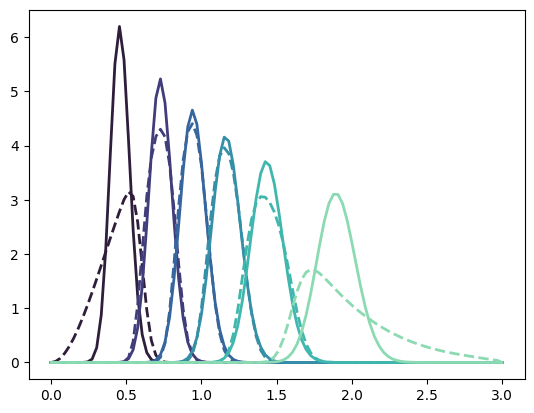

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("mako", 6)
print(my_dndz_norm_gp_she.shape)
for i in range(6):
    plt.plot(
        myz,
        my_dndz_norm_gp_she[i],
        color=palette[i],
        lw=2
    )
    plt.plot(myz, my_dndz_she_norm[i], color=palette[i], linestyle='--', lw=2)

In [10]:
print('No GP:', my_dndz_she_norm)
print('GP:', my_dndz_norm_gp_she)

No GP: [[ 1.14096700e-04  2.00550322e-02  7.84015789e-02  1.72650076e-01
   2.99660523e-01  4.55888258e-01  6.37536441e-01  8.40682783e-01
   1.06134683e+00  1.29559489e+00  1.53959511e+00  1.78966796e+00
   2.04233376e+00  2.29434091e+00  2.54264715e+00  2.78361236e+00
   3.00476820e+00  3.14881541e+00  3.06524596e+00  2.59084239e+00
   1.78622467e+00  9.67806143e-01  4.07051595e-01  1.33440972e-01
   3.45364780e-02  7.17334839e-03  1.22277491e-03  1.74418271e-04
   3.04170199e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   